In [28]:
# Consolidated imports for image EDA and preprocessing
# Includes data handling, numerical ops, plotting, filesystem helpers, image I/O, regex utilities, file copying, OpenCV, and train/validation/test splitting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import pickle
import re
import shutil
import cv2
from sklearn.model_selection import train_test_split
from typing import Optional, Tuple


# Image EDA and Preprocessing Overview
This notebook inspects and prepares the project image dataset for modeling.
It performs the following high-level tasks:
1. Load clinical metadata checkpoint created by the tabular pipeline.
2. Walk the `Images/` folder to collect image metadata (dimensions, encoding, path tokens).
3. Categorize images into anatomical regions and sides, detect corrupted files.
4. Normalize file naming conventions and create a unified `normalized_file_name`.
5. Compute dataset statistics and visual summaries.
6. Preprocess images (logo removal, hair removal, background masking, cropping, resize).
7. Validate resized outputs, create labeled image manifest, and perform patient-level train/val/test splits.

Run cells in order. The notebook preserves original processing logic while providing clearer documentation for each step.

## Load clinical checkpoint and collect image metadata
Load the cleaned tabular dataframe produced earlier and scan the `Images/` directory to build a master image metadata table.
The resulting `df_all` contains per-image attributes used throughout the analysis. Corrupted or unreadable images are recorded separately.

In [2]:
# Load the cleaned clinical dataframe and build an image metadata table by walking Images/
with open('cleaned_tabular_checkpoint.pkl', 'rb') as f:
    df_merged = pickle.load(f)

print(f"Clinical DataFrame loaded with {len(df_merged)} rows")

base_dir = Path('Images')
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
records = []
corrupted_files = []

for img_path in base_dir.rglob('*'):
    if img_path.is_file() and img_path.suffix.lower() in image_extensions:
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                mode = img.mode

            path_parts = list(img_path.parts)

            subject = None
            if 'Images' in path_parts:
                images_index = path_parts.index('Images')
                if images_index + 1 < len(path_parts):
                    subject = path_parts[images_index + 1]

            side = ''
            region = ''

            for part in path_parts:
                part_clean = str(part).strip()

                if part_clean in ['L', 'R']:
                    side = part_clean

                if part_clean in ['Ant', 'Post', 'Med', 'Let', 'Lat']:
                    if part_clean == 'Let':
                        region = 'Lat'
                    else:
                        region = part_clean

            records.append({
                'file_name': img_path.name,
                'file_path': str(img_path),
                'subject': subject,
                'side': side,
                'region': region,
                'extension': img_path.suffix.lower(),
                'width': width,
                'height': height,
                'aspect_ratio': width / height if height != 0 else np.nan,
                'mode': mode
            })

        except Exception as e:
            corrupted_files.append({
                'file_name': img_path.name,
                'file_path': str(img_path),
                'error': str(e)
            })

df_all = pd.DataFrame(records)
df_corrupted = pd.DataFrame(corrupted_files)

print(f"Total readable images found: {len(df_all)}")
print(f"Total corrupted/unreadable image files: {len(df_corrupted)}")

display(df_all.head())

if not df_corrupted.empty:
    print("Corrupted files:")
    display(df_corrupted)


Clinical DataFrame loaded with 432 rows
Total readable images found: 1557
Total corrupted/unreadable image files: 0


,file_name,file_path,subject,side,region,extension,width,height,aspect_ratio,mode
0,10-TA Scale.JPG,Images\10-TA\10-TA Scale.JPG,10-TA,,,.jpg,732,503,1.455268,RGB
1,17DS-Scale.JPG,Images\17-DS\17DS-Scale.JPG,17-DS,,,.jpg,736,504,1.460317,RGB
2,20AS-Scale.JPG,Images\20-AS\20AS-Scale.JPG,20-AS,,,.jpg,728,492,1.479675,RGB
3,21OD-Scale.JPG,Images\21-OD\21OD-Scale.JPG,21-OD,,,.jpg,727,494,1.471660,RGB
4,63NB-22mar18-Scale.JPG,Images\63-NB\63NB-22mar18-Scale.JPG,63-NB,,,.jpg,729,491,1.484725,RGB


## Categorize images by anatomical region and side
Split the master image table into convenient region/side subsets used for per-region analysis, and place all uncategorized rows into `Unknown`.

In [3]:
# Create dictionary of DataFrames partitioned by region/side for downstream summaries
dfs = {}

if not df_all.empty:
    dfs['Ant'] = df_all[df_all['region'] == 'Ant'].copy().reset_index(drop=True)
    dfs['Post'] = df_all[df_all['region'] == 'Post'].copy().reset_index(drop=True)
    dfs['L-Lat'] = df_all[(df_all['side'] == 'L') & (df_all['region'] == 'Lat')].copy().reset_index(drop=True)
    dfs['L-Med'] = df_all[(df_all['side'] == 'L') & (df_all['region'] == 'Med')].copy().reset_index(drop=True)
    dfs['R-Lat'] = df_all[(df_all['side'] == 'R') & (df_all['region'] == 'Lat')].copy().reset_index(drop=True)
    dfs['R-Med'] = df_all[(df_all['side'] == 'R') & (df_all['region'] == 'Med')].copy().reset_index(drop=True)
    
    known_conditions = (
        (df_all['region'] == 'Ant') | 
        (df_all['region'] == 'Post') | 
        ((df_all['side'] == 'L') & (df_all['region'] == 'Lat')) |
        ((df_all['side'] == 'L') & (df_all['region'] == 'Med')) |
        ((df_all['side'] == 'R') & (df_all['region'] == 'Lat')) |
        ((df_all['side'] == 'R') & (df_all['region'] == 'Med'))
    )
    
    dfs['Unknown'] = df_all[~known_conditions].copy().reset_index(drop=True)

else:
    for key in ['Ant', 'Post', 'L-Lat', 'L-Med', 'R-Lat', 'R-Med', 'Unknown']:
        dfs[key] = pd.DataFrame()

print("--- Image Counts by Category ---")
for key, df in dfs.items():
    print(f"{key} images: {len(df)}")

total_in_dfs = sum(len(df) for df in dfs.values())
print(f"\nTotal categorized: {total_in_dfs}")
print(f"Master DataFrame size: {len(df_all)}")


--- Image Counts by Category ---
Ant images: 450
Post images: 164
L-Lat images: 139
L-Med images: 142
R-Lat images: 142
R-Med images: 144
Unknown images: 376

Total categorized: 1557
Master DataFrame size: 1557


## Filter out unwanted files by filename or path
Remove known nuisance files such as photos that contain scale overlays and any file whose path indicates `unknown`. This step keeps the dataset focused on useful images.

In [4]:
# Remove images with filenames or paths that indicate they are not usable
if 'file_name' not in df_all.columns or 'file_path' not in df_all.columns:
    raise KeyError("df_all must contain both 'file_name' and 'file_path' columns.")

before_total = len(df_all)
remove_mask_all = (
    df_all['file_name'].astype(str).str.contains('scale', case=False, na=False)
    |
    df_all['file_path'].astype(str).str.contains('unknown', case=False, na=False)
)
df_all = df_all.loc[~remove_mask_all].reset_index(drop=True)
removed_total = before_total - len(df_all)

print(f"df_all: removed {removed_total} rows ('scale' in file_name OR 'unknown' in file_path) ({before_total} -> {len(df_all)})")

if 'dfs' in locals() and isinstance(dfs, dict):
    for key, frame in dfs.items():
        if isinstance(frame, pd.DataFrame) and 'file_name' in frame.columns and 'file_path' in frame.columns:
            before_n = len(frame)
            remove_mask = (
                frame['file_name'].astype(str).str.contains('scale', case=False, na=False)
                |
                frame['file_path'].astype(str).str.contains('unknown', case=False, na=False)
            )
            dfs[key] = frame.loc[~remove_mask].reset_index(drop=True)
            removed_n = before_n - len(dfs[key])
            print(f"{key}: removed {removed_n} rows ({before_n} -> {len(dfs[key])})")


df_all: removed 132 rows ('scale' in file_name OR 'unknown' in file_path) (1557 -> 1425)
Ant: removed 0 rows (450 -> 450)
Post: removed 0 rows (164 -> 164)
L-Lat: removed 0 rows (139 -> 139)
L-Med: removed 0 rows (142 -> 142)
R-Lat: removed 0 rows (142 -> 142)
R-Med: removed 0 rows (144 -> 144)
Unknown: removed 132 rows (376 -> 244)


## Filename normalization rules
We derive a normalized filename for each image using its parsed metadata and DataFrame membership.
The normalized format is `{subject}_{visit}_{knee_side}_{region}.{ext}` and is assigned to the `normalized_file_name` column.

In [5]:
# Helper functions to extract visit/side/region and build normalized filenames
def _clean_token(value: Optional[str]) -> str:
    if value is None:
        return 'unknown'
    text = str(value).strip().lower()
    text = re.sub(r"\(copy\)|\(\d+\)$", "", text)
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text if text else 'unknown'

def _extract_visit(file_path: str, file_name: str) -> str:
    text = f"{file_path} {file_name}".lower()
    if 'baseline' in text:
        return 'Baseline'
    fu_match = re.search(r"\bfu\s*([1-9])\b", text) or re.search(r"\bfu([1-9])\b", text)
    if fu_match:
        return f"FU{fu_match.group(1)}"
    if 'end of treatment' in text:
        return 'EndOfTreatment'
    if 'end of trial' in text:
        return 'EndOfTrial'
    return 'UnknownVisit'

def _extract_side(file_path: str, file_name: str) -> str:
    text = f"{file_path} {file_name}".lower()
    if re.search(r"\bknee[_\-\s]?left\b|\bleft\b|/l/", text):
        return 'L'
    if re.search(r"\bknee[_\-\s]?right\b|\bright\b|/r/", text):
        return 'R'
    return 'unknownside'

def _extract_region(file_path: str, file_name: str) -> str:
    text = f"{file_path} {file_name}".lower()
    if re.search(r"\blet\b|\blat\b|\blateral\b", text):
        return 'Lat'
    if re.search(r"\bmed\b|\bmedial\b", text):
        return 'Med'
    if re.search(r"\bant\b|\banterior\b", text):
        return 'Ant'
    if re.search(r"\bpost\b|\bposterior\b", text):
        return 'Post'
    return 'unknownregion'

def _infer_side_region_from_df_name(df_name: str, file_path: str, file_name: str) -> Tuple[str, str]:
    mapping = {
        'Ant': ('NA', 'Ant'),
        'Post': ('NA', 'Post'),
        'L-Lat': ('L', 'Lat'),
        'L-Med': ('L', 'Med'),
        'R-Lat': ('R', 'Lat'),
        'R-Med': ('R', 'Med'),
    }
    if df_name in mapping:
        return mapping[df_name]
    return _extract_side(file_path, file_name), _extract_region(file_path, file_name)

def _normalize_filename_row(row: pd.Series, df_name: str) -> str:
    subject_raw = str(row.get('subject', 'unknownsubject')).strip()
    subject = subject_raw if subject_raw else 'unknownsubject'
    visit = _extract_visit(str(row.get('file_path', '')), str(row.get('file_name', '')))
    side, region = _infer_side_region_from_df_name(df_name=df_name, file_path=str(row.get('file_path', '')), file_name=str(row.get('file_name', '')))
    ext = str(row.get('extension', '')).strip().lower()
    if not ext.startswith('.'):
        ext = f'.{ext}' if ext else '.jpg'
    normalized = f"{subject}_{visit}_{side}_{region}{ext}"
    normalized = re.sub(r"_+", "_", normalized).replace("_.", ".")
    return normalized

normalized_pairs = []
for df_name, frame in dfs.items():
    if frame.empty or 'file_path' not in frame.columns:
        continue
    frame_local = frame.copy()
    frame_local['normalized_file_name'] = frame_local.apply(lambda row: _normalize_filename_row(row, df_name=df_name), axis=1)
    dfs[df_name] = frame_local
    normalized_pairs.append(frame_local[['file_path', 'normalized_file_name']])

if normalized_pairs:
    mapping_df = pd.concat(normalized_pairs, ignore_index=True).drop_duplicates(subset=['file_path'])
    df_all = df_all.merge(mapping_df, on='file_path', how='left')
else:
    df_all['normalized_file_name'] = pd.NA

def _fallback_normalized_for_uncategorized(row: pd.Series) -> str:
    subject_raw = str(row.get('subject', 'unknownsubject')).strip()
    subject = subject_raw if subject_raw else 'unknownsubject'
    visit = _extract_visit(str(row.get('file_path', '')), str(row.get('file_name', '')))
    side = _extract_side(str(row.get('file_path', '')), str(row.get('file_name', '')))
    region = _extract_region(str(row.get('file_path', '')), str(row.get('file_name', '')))
    ext = str(row.get('extension', '')).strip().lower()
    if not ext.startswith('.'):
        ext = f'.{ext}' if ext else '.jpg'
    return f"{subject}_{visit}_{side}_{region}{ext}"

missing_mask = df_all['normalized_file_name'].isna()
if missing_mask.any():
    df_all.loc[missing_mask, 'normalized_file_name'] = df_all.loc[missing_mask].apply(_fallback_normalized_for_uncategorized, axis=1)

dup_count = int(df_all['normalized_file_name'].duplicated().sum())
print(f"Normalized names created for {len(df_all)} rows.")
print(f"Duplicate normalized names: {dup_count}")
display(df_all[['file_name', 'normalized_file_name', 'subject', 'side', 'region']].head(15))


Normalized names created for 1425 rows.
Duplicate normalized names: 886


,file_name,normalized_file_name,subject,side,region
0,10TA-21aug17_Baseline_1Ant.tiff,10-TA_Baseline_NA_Ant.tiff,10-TA,,Ant
1,10TA-21aug17_Baseline_1Post.tiff,10-TA_Baseline_NA_Post.tiff,10-TA,,Post
2,10TA-21aug17_Baseline_2Lat-Left.tiff,10-TA_Baseline_L_Lat.tiff,10-TA,L,Lat
3,10TA-21aug17_Baseline_2Med-Left.tiff,10-TA_Baseline_L_Med.tiff,10-TA,L,Med
4,10TA-21aug17_Baseline_2Lat-Right.tiff,10-TA_Baseline_R_Lat.tiff,10-TA,R,Lat
5,10TA-21aug17_Baseline_2Med-Right.tiff,10-TA_Baseline_R_Med.tiff,10-TA,R,Med
6,10TA-11jan18_EndTrial_1Ant.tiff,10-TA_FU3_NA_Ant.tiff,10-TA,,Ant
7,10TA-11jan18_EndTrial_3Ant-Left.tiff,10-TA_FU3_NA_Ant.tiff,10-TA,,Ant
8,10TA-11jan18_EndTrial_3Ant-Right.tiff,10-TA_FU3_NA_Ant.tiff,10-TA,,Ant
9,10TA-11jan18_EndTrial_1Post.tiff,10-TA_FU3_NA_Post.tiff,10-TA,,Post


## Visual style and plotting utilities
Set plotting theme and prepare libraries used for the visual summaries that follow.

In [6]:
# Configure plotting aesthetic defaults for all visualizations
sns.set_theme(style='whitegrid')


## Dataset summaries and distributions
Plot counts per region, image dimension distributions, and check for corrupted files. These summaries help identify obvious data quality issues.

C:\Users\shiri\AppData\Local\Temp\ipykernel_17160\771462443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_all, x='region', order=['Ant', 'Post', 'Med', 'Lat'], palette='viridis')


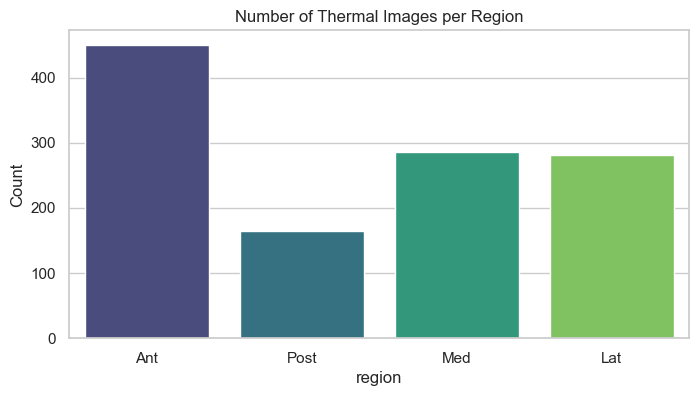

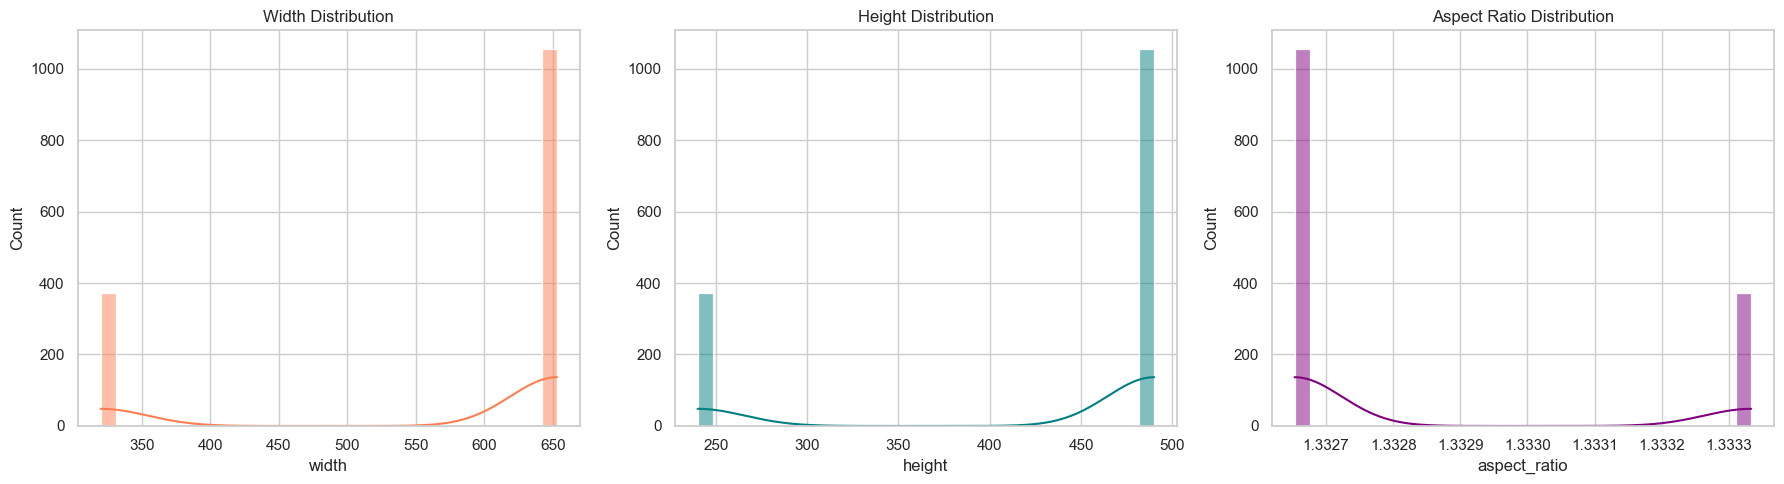

All image files are intact and readable.


In [7]:
# Distribution of images across regions and basic dimension histograms
plt.figure(figsize=(8, 4))
sns.countplot(data=df_all, x='region', order=['Ant', 'Post', 'Med', 'Lat'], palette='viridis')
plt.title('Number of Thermal Images per Region')
plt.ylabel('Count')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=df_all, x='width', bins=30, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Width Distribution')

sns.histplot(data=df_all, x='height', bins=30, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Height Distribution')

sns.histplot(data=df_all, x='aspect_ratio', bins=30, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Aspect Ratio Distribution')

plt.tight_layout()
plt.show()

if 'corrupted_files' in locals() and len(corrupted_files) > 0:
    print(f"Warning: Found {len(corrupted_files)} corrupted files.")
else:
    print('All image files are intact and readable.')


In [8]:
# Image-size statistics and resolution counts
required_cols = ['width', 'height', 'aspect_ratio']
missing = [c for c in required_cols if c not in df_all.columns]
if missing:
    raise KeyError(f"Missing required columns in df_all: {missing}")

size_df = df_all[required_cols].copy()
size_df['width'] = pd.to_numeric(size_df['width'], errors='coerce')
size_df['height'] = pd.to_numeric(size_df['height'], errors='coerce')
size_df['aspect_ratio'] = pd.to_numeric(size_df['aspect_ratio'], errors='coerce')
size_df['area'] = size_df['width'] * size_df['height']

print(f"Total images: {len(df_all)}")
print(f"Valid size rows: {len(size_df.dropna(subset=['width', 'height']))}")

size_stats = size_df.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T
display(size_stats)

extra_stats = pd.DataFrame({
    'variance': size_df.var(numeric_only=True),
    'skewness': size_df.skew(numeric_only=True),
    'kurtosis': size_df.kurtosis(numeric_only=True),
})
display(extra_stats)

resolution_counts = (
    df_all.assign(resolution=df_all['width'].astype(str) + 'x' + df_all['height'].astype(str))
          .groupby('resolution')
          .size()
          .reset_index(name='count')
          .sort_values(['count', 'resolution'], ascending=[False, True])
          .reset_index(drop=True)
)

print(f"Unique resolutions: {len(resolution_counts)}")
display(resolution_counts)


Total images: 1425
Valid size rows: 1425


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
width,1425.0,566.303158,146.180373,320.000000,320.000000,320.000000,320.000000,320.000000,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000
height,1425.0,424.912281,109.745025,240.000000,240.000000,240.000000,240.000000,240.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000
aspect_ratio,1425.0,1.332830,0.000299,1.332653,1.332653,1.332653,1.332653,1.332653,1.332653,1.333333,1.333333,1.333333,1.333333,1.333333
area,1425.0,256660.477193,106746.790997,76800.000000,76800.000000,76800.000000,76800.000000,76800.000000,319970.000000,319970.000000,319970.000000,319970.000000,319970.000000,319970.000000


,variance,skewness,kurtosis
width,2.136870e+04,-1.09338,-0.805654
height,1.204397e+04,-1.09338,-0.805654
aspect_ratio,8.917744e-08,1.09338,-0.805654
area,1.139488e+10,-1.09338,-0.805654


Unique resolutions: 2


,resolution,count
0,653x490,1054
1,320x240,371


## Image size normalization and preprocessing pipeline
The following functions implement deterministic preprocessing steps used to prepare each image for modeling: logo removal, hair removal, background masking, subject cropping, and resizing to a fixed target size.

In [9]:
# Preprocessing helpers for logo removal, hair removal, background masking, and subject cropping
def remove_logo(image_array, width_ratio=0.20, height_ratio=0.15):
    image_array_copy = image_array.copy()
    h, w = image_array_copy.shape[:2]
    crop_h = int(h * height_ratio)
    crop_w = int(w * width_ratio)
    image_array_copy[0:crop_h, 0:crop_w] = (0, 0, 0)
    return image_array_copy

def remove_hair_dullrazor(image_array, kernel_size=(9, 9), threshold_val=20, inpaint_rad=2):
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, threshold_val, 255, cv2.THRESH_BINARY)
    closing_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    hair_mask = cv2.morphologyEx(hair_mask, cv2.MORPH_CLOSE, closing_kernel)
    cleaned_image = cv2.inpaint(image_array, hair_mask, inpaint_rad, cv2.INPAINT_TELEA)
    return cleaned_image

def mask_background(image_array, threshold_val=15, min_area_ratio=0.01):
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold_val, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image_array
    mask = np.zeros_like(gray)
    image_area = gray.shape[0] * gray.shape[1]
    min_area = image_area * min_area_ratio
    for cnt in contours:
        if cv2.contourArea(cnt) > min_area:
            cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
    result = cv2.bitwise_and(image_array, image_array, mask=mask)
    return result

def crop_to_subject(image_array, threshold_val=15, min_area_ratio=0.01):
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold_val, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image_array
    image_area = gray.shape[0] * gray.shape[1]
    min_area = image_area * min_area_ratio
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
    if not valid_contours:
        return image_array
    x_min = min(cv2.boundingRect(c)[0] for c in valid_contours)
    y_min = min(cv2.boundingRect(c)[1] for c in valid_contours)
    x_max = max(cv2.boundingRect(c)[0] + cv2.boundingRect(c)[2] for c in valid_contours)
    y_max = max(cv2.boundingRect(c)[1] + cv2.boundingRect(c)[3] for c in valid_contours)
    padding = 5
    y1 = max(0, y_min - padding)
    y2 = min(image_array.shape[0], y_max + padding)
    x1 = max(0, x_min - padding)
    x2 = min(image_array.shape[1], x_max + padding)
    return image_array[y1:y2, x1:x2]


### Preprocessing pipeline and resizing
Run the deterministic pipeline over all images and save resized copies to `Images_Cleaned_256/`. The pipeline keeps a manifest of successfully processed files and any errors encountered.

In [10]:
# Execute the preprocessing pipeline: apply helpers, resize, and record outputs
target_size = (256, 256)
resized_root = Path('Images_Cleaned_256')
cleaned_records = []
clean_errors = []

print(f"Starting full preprocessing pipeline for {len(df_all)} images. This may take a few minutes...")

for idx, src in enumerate(df_all['file_path'].astype(str)):
    src_path = Path(src)
    dst_path = resized_root / src_path.relative_to(base_dir)
    dst_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        img_bgr = cv2.imread(str(src_path))
        if img_bgr is None:
            raise ValueError(f"Could not load image from {src_path}")
        img_no_logo = remove_logo(img_bgr, width_ratio=0.20, height_ratio=0.15)
        img_no_hair = remove_hair_dullrazor(img_no_logo)
        img_masked = mask_background(img_no_hair)
        img_cropped = crop_to_subject(img_masked)
        img_rgb = cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB)
        im_pil = Image.fromarray(img_rgb)
        im_resized = im_pil.resize(target_size, Image.Resampling.BILINEAR)
        im_resized.save(dst_path)
        cleaned_records.append({
            'file_path': str(src_path),
            'resized_file_path': str(dst_path),
            'resized_width': target_size[0],
            'resized_height': target_size[1],
            'resized_mode': 'RGB',
        })
    except Exception as e:
        clean_errors.append({'file_path': str(src_path), 'error': str(e)})
    if (idx + 1) % 200 == 0:
        print(f"Processed {idx + 1}/{len(df_all)}...")

df_cleaned = pd.DataFrame(cleaned_records)
df_clean_errors = pd.DataFrame(clean_errors)
df_all = df_all.merge(df_cleaned, on='file_path', how='left')

print(f"\nSuccessfully cleaned and resized: {len(df_cleaned)}")
if not df_clean_errors.empty:
    print(f"Failed: {len(df_clean_errors)}")


Starting full preprocessing pipeline for 1425 images. This may take a few minutes...
Processed 200/1425...
Processed 400/1425...
Processed 600/1425...
Processed 800/1425...
Processed 1000/1425...
Processed 1200/1425...
Processed 1400/1425...

Successfully cleaned and resized: 1424
Failed: 1


## Validation of resized outputs
Confirm that resized images share identical dimensions and surface any unexpected discrepancies.

In [11]:
# Validate resized image dimensions and report any mismatches
print('=' * 60)
print('IMAGE SIZE VALIDATION')
print('=' * 60)

if 'resized_width' in df_all.columns and 'resized_height' in df_all.columns:
    unique_sizes = df_all[['resized_width', 'resized_height']].drop_duplicates()
    print(f"\nUnique resized dimensions found: {len(unique_sizes)}")
    display(unique_sizes)
    if len(unique_sizes) == 1:
        width = unique_sizes['resized_width'].iloc[0]
        height = unique_sizes['resized_height'].iloc[0]
        print(f"\n✓ SUCCESS: All {len(df_all)} images are uniformly resized to {width}x{height}")
    else:
        print(f"\n✗ WARNING: Found {len(unique_sizes)} different sizes!")
        size_counts = df_all.groupby(['resized_width', 'resized_height']).size().reset_index(name='count')
        display(size_counts)
else:
    print('Resized metadata columns not found. Checking original dimensions...')
    unique_sizes = df_all[['width', 'height']].drop_duplicates()
    print(f"Unique original dimensions: {len(unique_sizes)}")
    display(unique_sizes)


IMAGE SIZE VALIDATION

Unique resized dimensions found: 2


,resized_width,resized_height
0,256.0,256.0
699,NaN,NaN



✗ WARNING: Found 2 different sizes!


,resized_width,resized_height,count
0,256.0,256.0,1424


## Visual samples and per-class displays
Show representative images per region and per-class example images to inspect visual patterns and ensure preprocessing preserved relevant structure.

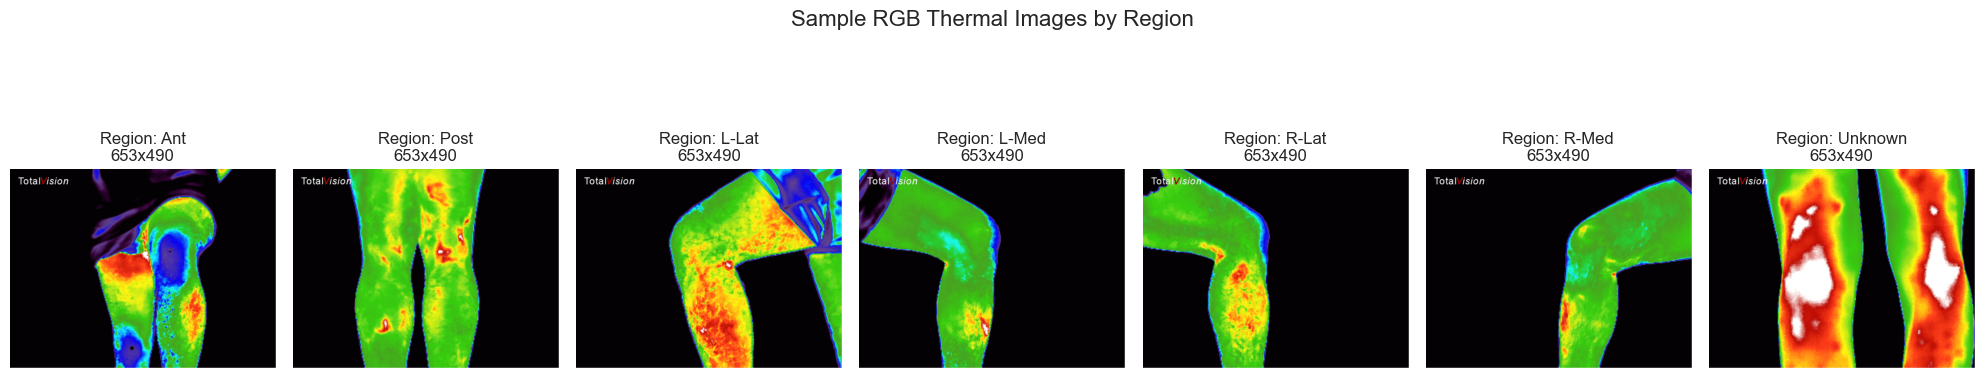

In [12]:
# Display one random thermal image from each region
fig, axes = plt.subplots(1, len(dfs), figsize=(20, 5))

for ax, (region, df) in zip(axes, dfs.items()):
    if not df.empty:
        sample_path = df.sample(1, random_state=42)['file_path'].values[0]
        img = Image.open(sample_path)
        ax.imshow(img)
        ax.set_title(f'Region: {region}\n{img.size[0]}x{img.size[1]}', fontsize=12)
        ax.axis('off')
    else:
        ax.set_title(f'Region: {region} (No Data)')
        ax.axis('off')

plt.suptitle('Sample RGB Thermal Images by Region', fontsize=16)
plt.tight_layout()
plt.show()


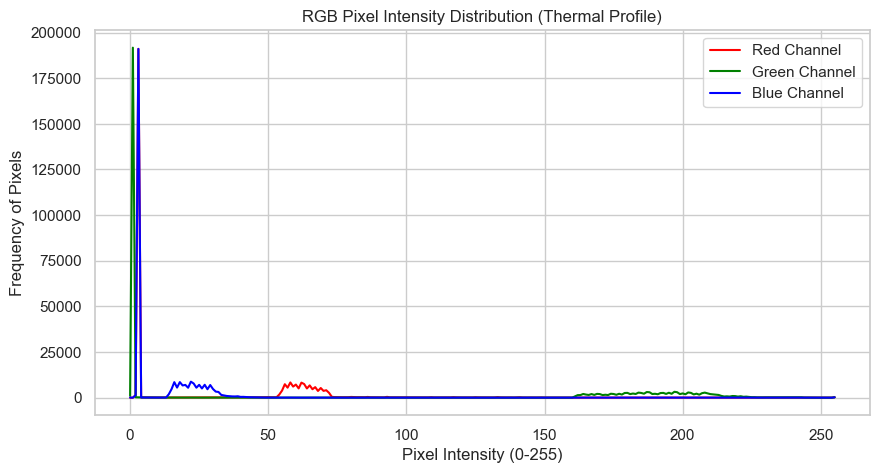

In [13]:
# RGB channel intensity distribution for a random sample image
sample_path = df_all.sample(1, random_state=10)['file_path'].values[0]
img_array = np.array(Image.open(sample_path).convert('RGB'))
plt.figure(figsize=(10, 5))
colors = ('red', 'green', 'blue')
for i, color in enumerate(colors):
    hist, bins = np.histogram(img_array[:, :, i], bins=256, range=(0, 256))
    plt.plot(bins[:-1], hist, color=color, label=f'{color.capitalize()} Channel')
plt.title('RGB Pixel Intensity Distribution (Thermal Profile)')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency of Pixels')
plt.legend()
plt.show()


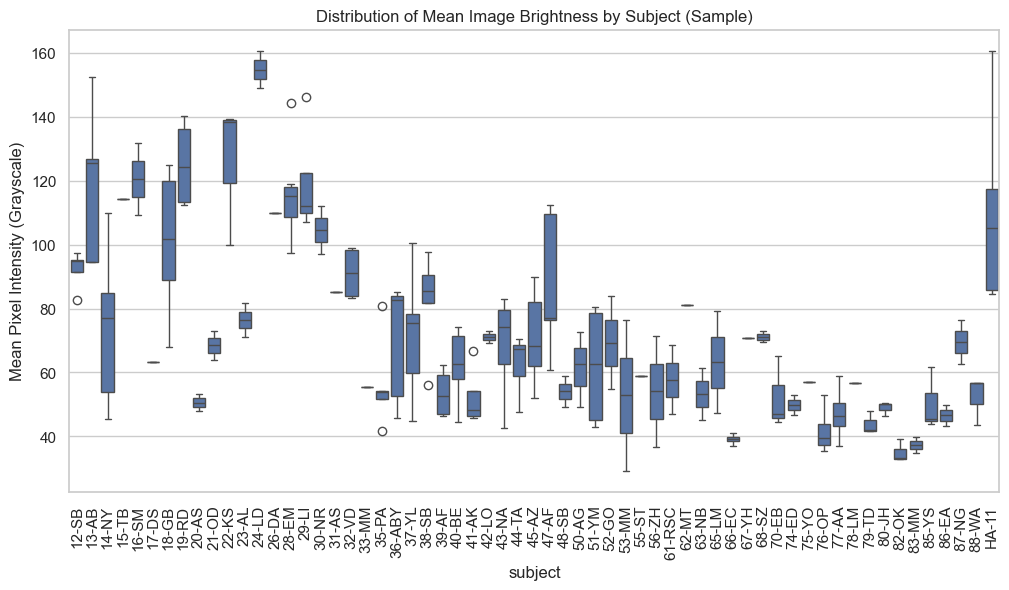

In [14]:
# Mean brightness per image for a random subset to explore per-subject variation
def get_mean_brightness(filepath):
    try:
        img = Image.open(filepath).convert('L')
        return np.mean(np.array(img))
    except:
        return np.nan

sample_df = df_all.sample(min(200, len(df_all)), random_state=42).copy()
sample_df['mean_brightness'] = sample_df['file_path'].apply(get_mean_brightness)
plt.figure(figsize=(12, 6))
sns.boxplot(data=sample_df.sort_values('subject'), x='subject', y='mean_brightness')
plt.title('Distribution of Mean Image Brightness by Subject (Sample)')
plt.xticks(rotation=90)
plt.ylabel('Mean Pixel Intensity (Grayscale)')
plt.show()


## PN and Visit cross-checks between Excel and image sources
The following cells normalize PN identifiers and compare the PN sets and PN+Visit pairs present in the clinical table (`df_merged`) and the image metadata (`df_all`). This helps diagnose missing linkage between modalities.

In [15]:
# Helpers for PN normalization and visit inference from image metadata
def normalize_pn(value: object) -> str:
    text = str(value).strip().upper().replace('_', '-').replace(' ', '')
    text = re.sub(r'[^A-Z0-9-]', '', text)
    num_first = re.match(r'^(\d{1,3})-([A-Z]{1,4})$', text)
    if num_first:
        return f"{num_first.group(2)}-{num_first.group(1).zfill(2)}"
    letters_first = re.match(r'^([A-Z]{1,4})-(\d{1,3})$', text)
    if letters_first:
        return f"{letters_first.group(1)}-{letters_first.group(2).zfill(2)}"
    return text

def extract_visit_label_from_image_row(row: pd.Series) -> str:
    text = f"{row.get('file_path', '')} {row.get('file_name', '')} {row.get('normalized_file_name', '')}".lower()
    if 'baseline' in text:
        return 'Baseline'
    if re.search(r'\bfu\s*1\b|\bfu1\b', text):
        return 'FU1'
    if re.search(r'\bfu\s*3\b|\bfu3\b', text):
        return 'FU3'
    return 'UnknownVisit'


In [16]:
# PN set cross-check: ensure PN values are comparable between data sources
if 'df_merged' not in globals() or not isinstance(df_merged, pd.DataFrame):
    raise NameError("df_merged is not available. Run the Excel preprocessing cells first.")
if 'df_all' not in globals() or not isinstance(df_all, pd.DataFrame):
    raise NameError("df_all is not available. Run the image EDA collection cells first.")
if 'PN' not in df_merged.columns:
    raise KeyError("df_merged must contain a 'PN' column.")
if 'subject' not in df_all.columns:
    raise KeyError("df_all must contain a 'subject' column.")

excel_pn_set = {normalize_pn(v) for v in df_merged['PN'].dropna().astype(str) if str(v).strip()}
image_pn_set = {normalize_pn(v) for v in df_all['subject'].dropna().astype(str) if str(v).strip()}

excel_not_in_images = sorted(excel_pn_set - image_pn_set)
images_not_in_excel = sorted(image_pn_set - excel_pn_set)

print('=== PN Cross-Check Summary ===')
print(f"Unique PN in Excel (df_merged): {len(excel_pn_set)}")
print(f"Unique PN in Images (df_all.subject): {len(image_pn_set)}")
print(f"In Excel but not in Images: {len(excel_not_in_images)}")
print(f"In Images but not in Excel: {len(images_not_in_excel)}")

excel_missing_df = pd.DataFrame({'PN_in_excel_not_in_images': excel_not_in_images})
images_missing_df = pd.DataFrame({'PN_in_images_not_in_excel': images_not_in_excel})

print('\nPNs in Excel but missing in Images:')
display(excel_missing_df)

print('\nPNs in Images but missing in Excel:')
display(images_missing_df)


=== PN Cross-Check Summary ===
Unique PN in Excel (df_merged): 76
Unique PN in Images (df_all.subject): 72
In Excel but not in Images: 11
In Images but not in Excel: 7

PNs in Excel but missing in Images:


,PN_in_excel_not_in_images
0,AA-01
1,AB-03
2,AM-08
3,AP-05
4,CH-07
5,DM-71
6,GA-06
7,MC-02
8,SB-57
9,TO-72



PNs in Images but missing in Excel:


,PN_in_images_not_in_excel
0,AA-77
1,AK-41
2,EA-84
3,EB-70
4,LD-24
5,SB-12
6,TD-79


In [17]:
# Restrict both sources to shared PN only so subsequent image-label joins are deterministic
if 'df_merged' not in globals() or 'df_all' not in globals():
    raise NameError("df_merged and df_all must exist before running this cell.")
if 'PN' not in df_merged.columns:
    raise KeyError("df_merged must contain a 'PN' column.")
if 'subject' not in df_all.columns:
    raise KeyError("df_all must contain a 'subject' column.")

excel_before_rows = len(df_merged)
images_before_rows = len(df_all)

df_merged['_PN_norm'] = df_merged['PN'].apply(normalize_pn)
df_all['_PN_norm'] = df_all['subject'].apply(normalize_pn)

excel_set_before = set(df_merged['_PN_norm'].dropna())
images_set_before = set(df_all['_PN_norm'].dropna())

only_excel_before = sorted(excel_set_before - images_set_before)
only_images_before = sorted(images_set_before - excel_set_before)
shared_pn = excel_set_before & images_set_before

print('=== Before Filtering (from current data) ===')
print(f"Unique PN in Excel: {len(excel_set_before)}")
print(f"Unique PN in Images: {len(images_set_before)}")
print(f"Excel-only PN: {len(only_excel_before)}")
print(f"Images-only PN: {len(only_images_before)}")

df_merged = df_merged[df_merged['_PN_norm'].isin(shared_pn)].copy()
df_all = df_all[df_all['_PN_norm'].isin(shared_pn)].copy()

excel_after_rows = len(df_merged)
images_after_rows = len(df_all)

excel_set_after = set(df_merged['_PN_norm'].dropna())
images_set_after = set(df_all['_PN_norm'].dropna())

only_excel_after = sorted(excel_set_after - images_set_after)
only_images_after = sorted(images_set_after - excel_set_after)

print('\n=== After Filtering to Shared PN Only ===')
print(f"Rows in df_merged: {excel_before_rows} -> {excel_after_rows}")
print(f"Rows in df_all: {images_before_rows} -> {images_after_rows}")
print(f"Unique PN in Excel (after): {len(excel_set_after)}")
print(f"Unique PN in Images (after): {len(images_set_after)}")
print(f"Excel-only PN after filter: {len(only_excel_after)}")
print(f"Images-only PN after filter: {len(only_images_after)}")

df_merged.drop(columns=['_PN_norm'], inplace=True, errors='ignore')
df_all.drop(columns=['_PN_norm'], inplace=True, errors='ignore')


=== Before Filtering (from current data) ===
Unique PN in Excel: 76
Unique PN in Images: 72
Excel-only PN: 11
Images-only PN: 7

=== After Filtering to Shared PN Only ===
Rows in df_merged: 432 -> 368
Rows in df_all: 1425 -> 1300
Unique PN in Excel (after): 65
Unique PN in Images (after): 65
Excel-only PN after filter: 0
Images-only PN after filter: 0


## Visit inference and matching
Infer visit labels from image metadata and compare PN+Visit pairs between images and clinical data to identify mismatches.

In [18]:
# Compare PN+Visit combinations between the two sources
visit_map = {1: 'Baseline', 2: 'FU1', 3: 'FU3'}
excel_tmp = df_merged[['PN', 'Visit']].copy()
excel_tmp['PN_norm'] = excel_tmp['PN'].apply(normalize_pn)
excel_tmp['Visit_label'] = pd.to_numeric(excel_tmp['Visit'], errors='coerce').map(visit_map)
excel_tmp = excel_tmp.dropna(subset=['PN_norm', 'Visit_label'])
excel_pairs = {(pn, visit) for pn, visit in excel_tmp[['PN_norm', 'Visit_label']].drop_duplicates().itertuples(index=False)}
img_tmp = df_all.copy()
img_tmp['PN_norm'] = img_tmp['subject'].apply(normalize_pn)
img_tmp['Visit_label'] = img_tmp.apply(extract_visit_label_from_image_row, axis=1)
unknown_visit_count = int((img_tmp['Visit_label'] == 'UnknownVisit').sum())
img_tmp = img_tmp[img_tmp['Visit_label'].isin({'Baseline', 'FU1', 'FU3'})]
image_pairs = {(pn, visit) for pn, visit in img_tmp[['PN_norm', 'Visit_label']].drop_duplicates().itertuples(index=False)}
excel_not_in_images = sorted(excel_pairs - image_pairs)
images_not_in_excel = sorted(image_pairs - excel_pairs)
print('=== PN + Visit Cross-Check Summary ===')
print(f"Unique PN+Visit pairs in Excel: {len(excel_pairs)}")
print(f"Unique PN+Visit pairs in Images: {len(image_pairs)}")
print(f"In Excel but not in Images: {len(excel_not_in_images)}")
print(f"In Images but not in Excel: {len(images_not_in_excel)}")
excel_missing_df = pd.DataFrame(excel_not_in_images, columns=['PN', 'Visit'])
images_missing_df = pd.DataFrame(images_not_in_excel, columns=['PN', 'Visit'])
print('\nPN+Visit in Excel but missing in Images:')
display(excel_missing_df)
print('\nPN+Visit in Images but missing from Excel:')
display(images_missing_df)
print(f"\nRows with unmapped image visit label (ignored in comparison): {unknown_visit_count}")


=== PN + Visit Cross-Check Summary ===
Unique PN+Visit pairs in Excel: 185
Unique PN+Visit pairs in Images: 86
In Excel but not in Images: 108
In Images but not in Excel: 9

PN+Visit in Excel but missing in Images:


,PN,Visit
0,AB-13,FU1
1,AB-13,FU3
2,AF-39,FU3
3,AF-47,FU1
4,AF-47,FU3
...,...,...
103,YO-75,FU3
104,YS-85,FU1
105,YS-85,FU3
106,ZH-56,FU1



PN+Visit in Images but missing from Excel:


,PN,Visit
0,AB-13,Baseline
1,ABY-36,FU1
2,AF-39,FU1
3,AZ-45,FU1
4,BE-40,FU1
5,LO-42,FU1
6,NA-43,FU1
7,SM-16,Baseline
8,TA-10,Baseline



Rows with unmapped image visit label (ignored in comparison): 0


## Attach clinical labels to images by PN + Visit
Join image rows with their corresponding clinical `pain_label` using normalized PN and inferred visit. Images without matches are kept for inspection.

In [19]:
# Build labeled image manifest by merging image metadata with clinical labels
visit_label_to_num = {'Baseline': 1, 'FU1': 2, 'FU3': 3}
img = df_all.copy()
if 'normalized_file_name' not in img.columns:
    img['normalized_file_name'] = ''
img['PN_norm'] = img['subject'].apply(normalize_pn)
img['Visit_label'] = img.apply(extract_visit_label_from_image_row, axis=1)
img['Visit'] = img['Visit_label'].map(visit_label_to_num)
img_known = img[img['Visit'].notna()].copy()
img_known['Visit'] = img_known['Visit'].astype(int)
label_source_col = 'pain_label' if 'pain_label' in df_merged.columns else 'PF_DIAGNOSIS'
if label_source_col not in df_merged.columns:
    raise KeyError('df_merged must contain pain_label or PF_DIAGNOSIS for labeling.')
clin = df_merged[['PN', 'Visit', 'QUALITY', 'PF_DIAGNOSIS', label_source_col]].copy()
clin['PN_norm'] = clin['PN'].apply(normalize_pn)
clin['Visit'] = pd.to_numeric(clin['Visit'], errors='coerce')
clin = clin.dropna(subset=['PN_norm', 'Visit'])
clin['Visit'] = clin['Visit'].astype(int)
clin['pain_label'] = pd.to_numeric(clin[label_source_col], errors='coerce')
clin = clin[['PN_norm', 'Visit', 'QUALITY', 'PF_DIAGNOSIS', 'pain_label']].drop_duplicates()
df_images_labeled = img_known.merge(clin, on=['PN_norm', 'Visit'], how='left')
matched = int(df_images_labeled['pain_label'].notna().sum())
unmatched = int(df_images_labeled['pain_label'].isna().sum())
print('=== Image Labeling Summary ===')
print(f"Label source from df_merged: {label_source_col}")
print(f"Images with recognized visit label: {len(df_images_labeled)}")
print(f"Matched image labels: {matched}")
print(f"Unmatched image labels: {unmatched}")
print('\nPain label distribution (including NaN):')
print(df_images_labeled['pain_label'].value_counts(dropna=False).sort_index())
display_cols = [ 'subject', 'file_name', 'Visit_label', 'Visit', 'PN_norm', 'QUALITY', 'pain_label', 'file_path']
display_cols = [c for c in display_cols if c in df_images_labeled.columns]
print('\nSample labeled images:')
display(df_images_labeled[display_cols].head(20))
if unmatched > 0:
    print('\nSample unmatched rows (for debugging):')
    display(df_images_labeled[df_images_labeled['pain_label'].isna()][display_cols].head(20))


=== Image Labeling Summary ===
Label source from df_merged: pain_label
Images with recognized visit label: 1682
Matched image labels: 1553
Unmatched image labels: 129

Pain label distribution (including NaN):
pain_label
0.0     438
1.0    1115
NaN     129
Name: count, dtype: int64

Sample labeled images:


,subject,file_name,Visit_label,Visit,PN_norm,QUALITY,pain_label,file_path
0,10-TA,10TA-21aug17_Baseline_1Ant.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\Ant\10TA-21aug17_Baselin...
1,10-TA,10TA-21aug17_Baseline_1Post.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\Post\10TA-21aug17_Baseli...
2,10-TA,10TA-21aug17_Baseline_2Lat-Left.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\L\Let\10TA-21aug17_Basel...
3,10-TA,10TA-21aug17_Baseline_2Med-Left.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\L\Med\10TA-21aug17_Basel...
4,10-TA,10TA-21aug17_Baseline_2Lat-Right.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\R\Let\10TA-21aug17_Basel...
5,10-TA,10TA-21aug17_Baseline_2Med-Right.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\R\Med\10TA-21aug17_Basel...
6,10-TA,10TA-11jan18_EndTrial_1Ant.tiff,FU3,3,TA-10,1.0,1.0,Images\10-TA\FU3\Ant\10TA-11jan18_EndTrial_1An...
7,10-TA,10TA-11jan18_EndTrial_3Ant-Left.tiff,FU3,3,TA-10,1.0,1.0,Images\10-TA\FU3\Ant\10TA-11jan18_EndTrial_3An...
8,10-TA,10TA-11jan18_EndTrial_3Ant-Right.tiff,FU3,3,TA-10,1.0,1.0,Images\10-TA\FU3\Ant\10TA-11jan18_EndTrial_3An...
9,10-TA,10TA-11jan18_EndTrial_1Post.tiff,FU3,3,TA-10,1.0,1.0,Images\10-TA\FU3\Post\10TA-11jan18_EndTrial_1P...



Sample unmatched rows (for debugging):


,subject,file_name,Visit_label,Visit,PN_norm,QUALITY,pain_label,file_path
0,10-TA,10TA-21aug17_Baseline_1Ant.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\Ant\10TA-21aug17_Baselin...
1,10-TA,10TA-21aug17_Baseline_1Post.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\Post\10TA-21aug17_Baseli...
2,10-TA,10TA-21aug17_Baseline_2Lat-Left.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\L\Let\10TA-21aug17_Basel...
3,10-TA,10TA-21aug17_Baseline_2Med-Left.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\L\Med\10TA-21aug17_Basel...
4,10-TA,10TA-21aug17_Baseline_2Lat-Right.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\R\Let\10TA-21aug17_Basel...
5,10-TA,10TA-21aug17_Baseline_2Med-Right.tiff,Baseline,1,TA-10,NaN,NaN,Images\10-TA\Baseline\R\Med\10TA-21aug17_Basel...
14,13-AB,LLLAB115042026_21082017 728 PM.jpg,Baseline,1,AB-13,NaN,NaN,Images\13-AB\Baseline\Ant\LLLAB115042026_21082...
15,13-AB,LLLAB119042026_13AB 21082017 anterior.jpg,Baseline,1,AB-13,NaN,NaN,Images\13-AB\Baseline\Ant\LLLAB119042026_13AB ...
16,13-AB,LLLAB115042026_21082017 729 PM (1).jpg,Baseline,1,AB-13,NaN,NaN,Images\13-AB\Baseline\Color\LLLAB115042026_210...
17,13-AB,LLLAB115042026_21082017 729 PM (2).jpg,Baseline,1,AB-13,NaN,NaN,Images\13-AB\Baseline\Color\LLLAB115042026_210...


In [20]:
# Quick label sanity checks
if 'df_images_labeled' not in globals() or 'pain_label' not in df_images_labeled.columns:
    raise NameError('df_images_labeled with pain_label is not available. Run labeling cell first.')
print(f"Dataset size: {len(df_images_labeled)}")
print('\nPain label distribution (including NaN):')
print(df_images_labeled['pain_label'].value_counts(dropna=False).sort_index())


Dataset size: 1682

Pain label distribution (including NaN):
pain_label
0.0     438
1.0    1115
NaN     129
Name: count, dtype: int64


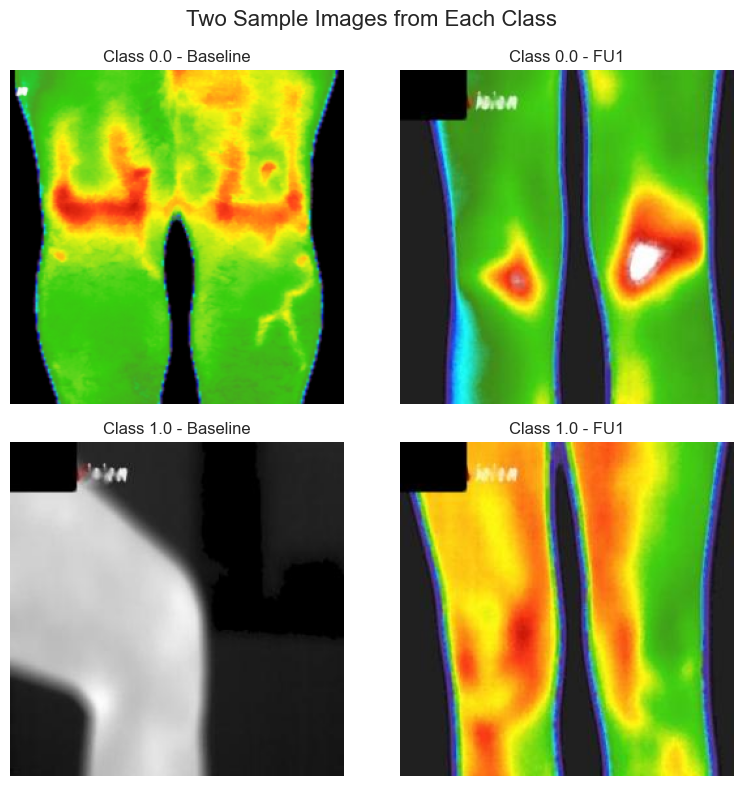

In [21]:
# Plot two sample images per class after labeling
if 'df_images_labeled' not in globals():
    raise NameError('df_images_labeled is not available. Run the image labeling cell first.')
plot_df = df_images_labeled.copy()
if 'pain_label' not in plot_df.columns:
    raise KeyError('df_images_labeled must contain a pain_label column.')
plot_df = plot_df[plot_df['pain_label'].notna()].copy()
plot_df['pain_label'] = pd.to_numeric(plot_df['pain_label'], errors='coerce')
plot_df = plot_df[plot_df['pain_label'].notna()].copy()
if plot_df.empty:
    raise ValueError('No labeled images were found to plot.')
classes = sorted(plot_df['pain_label'].unique())
nrows = len(classes)
ncols = 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 4 * nrows))
axes = np.atleast_2d(axes)
for row_idx, label in enumerate(classes):
    class_df = plot_df[plot_df['pain_label'] == label].sample(n=min(2, len(plot_df[plot_df['pain_label'] == label])), random_state=42)
    for col_idx in range(ncols):
        ax = axes[row_idx, col_idx]
        if col_idx < len(class_df):
            row = class_df.iloc[col_idx]
            img_path = row['resized_file_path'] if 'resized_file_path' in row and pd.notna(row['resized_file_path']) else row['file_path']
            with Image.open(img_path) as img:
                ax.imshow(img)
            ax.set_title(f"Class {label} - {row.get('Visit_label', 'Visit')}")
        else:
            ax.axis('off')
            continue
        ax.axis('off')
plt.suptitle('Two Sample Images from Each Class', fontsize=16)
plt.tight_layout()
plt.show()


## Patient-level train/validation/test split
Create patient-separated splits that preserve class balance as much as possible and export VM-ready CSV manifests.

In [22]:
# Build the patient-level split candidates and keep the existing label distribution as balanced as possible
if 'df_images_labeled' not in globals():
    raise NameError('df_images_labeled is not available. Run the image labeling cell first.')
split_df = df_images_labeled.copy()
split_df = split_df[split_df['pain_label'].notna()].copy()
split_df['pain_label'] = pd.to_numeric(split_df['pain_label'], errors='coerce')
split_df = split_df[split_df['pain_label'].notna()].copy()
split_df['pain_label'] = split_df['pain_label'].astype(int)
split_df['PN_norm'] = split_df['subject'].astype(str).str.strip().str.upper().str.replace('_', '-', regex=False)
unique_pns = split_df['PN_norm'].dropna().unique()
patient_labels = (split_df.groupby('PN_norm')['pain_label'].agg(lambda values: tuple(sorted(set(int(v) for v in values)))).reset_index(name='label_set'))
def label_set_to_strata(label_set: tuple) -> str:
    label_set = tuple(sorted(set(label_set)))
    if label_set == (0,):
        return 'class_0'
    if label_set == (1,):
        return 'class_1'
    if label_set == (0, 1):
        return 'mixed'
    raise ValueError(f"Unexpected patient label set: {label_set}")
patient_labels['strata'] = patient_labels['label_set'].apply(label_set_to_strata)
strata_by_pn = patient_labels.drop_duplicates(subset=['PN_norm']).set_index('PN_norm')['strata']
total_rows = len(split_df)
target_train_rows = int(round(total_rows * 0.70))
target_val_rows = int(round(total_rows * 0.10))
target_test_rows = total_rows - target_train_rows - target_val_rows
train_class0_floors = [200, 180, 160, 140, 0]
best_candidate = None
best_score = None
best_details = None
for min_train_class0 in train_class0_floors:
    for random_state in range(42, 2042):
        try:
            train_val_pns, test_pns = train_test_split(unique_pns, test_size=0.20, random_state=random_state, shuffle=True, stratify=strata_by_pn.loc[unique_pns])
            val_size_of_train_val = 0.10 / 0.80
            train_pns, val_pns = train_test_split(train_val_pns, test_size=val_size_of_train_val, random_state=random_state, shuffle=True, stratify=strata_by_pn.loc[train_val_pns])
            train_df_candidate = split_df[split_df['PN_norm'].isin(train_pns)].drop(columns=['PN_norm']).copy()
            val_df_candidate = split_df[split_df['PN_norm'].isin(val_pns)].drop(columns=['PN_norm']).copy()
            test_df_candidate = split_df[split_df['PN_norm'].isin(test_pns)].drop(columns=['PN_norm']).copy()
            train_counts = train_df_candidate['pain_label'].value_counts().reindex([0, 1], fill_value=0)
            val_counts = val_df_candidate['pain_label'].value_counts().reindex([0, 1], fill_value=0)
            test_counts = test_df_candidate['pain_label'].value_counts().reindex([0, 1], fill_value=0)
            if (train_counts.min() == 0) or (val_counts.min() == 0) or (test_counts.min() == 0):
                continue
            train_class0 = int(train_counts.get(0, 0))
            val_class0 = int(val_counts.get(0, 0))
            test_class0 = int(test_counts.get(0, 0))
            train_ratio = train_class0 / max(len(train_df_candidate), 1)
            val_ratio = val_class0 / max(len(val_df_candidate), 1)
            test_ratio = test_class0 / max(len(test_df_candidate), 1)
            val_gap = abs(val_ratio - 0.50)
            test_gap = abs(test_ratio - 0.50)
            worst_gap = max(val_gap, test_gap)
            total_gap = val_gap + test_gap
            size_error = (abs(len(train_df_candidate) - target_train_rows) / max(target_train_rows, 1) + abs(len(val_df_candidate) - target_val_rows) / max(target_val_rows, 1) + abs(len(test_df_candidate) - target_test_rows) / max(target_test_rows, 1))
            train_floor_penalty = max(0, min_train_class0 - train_class0) / max(min_train_class0, 1)
            train_ratio_penalty = max(0, 0.20 - train_ratio)
            score = (worst_gap * 20.0 + total_gap * 8.0 + size_error * 0.5 + train_floor_penalty * 2.0 + train_ratio_penalty * 1.0)
            if best_score is None or score < best_score:
                best_candidate = {'random_state': random_state, 'train_df': train_df_candidate, 'val_df': val_df_candidate, 'test_df': test_df_candidate, 'train_pns': train_pns, 'val_pns': val_pns, 'test_pns': test_pns, 'min_train_class0': min_train_class0}
                best_score = score
                best_details = {'train_counts': train_counts, 'val_counts': val_counts, 'test_counts': test_counts, 'train_ratio': train_ratio, 'val_ratio': val_ratio, 'test_ratio': test_ratio, 'train_class0': train_class0, 'val_class0': val_class0, 'test_class0': test_class0, 'val_gap': val_gap, 'test_gap': test_gap}
            if best_details is not None and best_details['val_gap'] <= 0.06 and best_details['test_gap'] <= 0.06 and min_train_class0 >= 140:
                break
        except ValueError:
            continue
    if best_details is not None and best_details['val_gap'] <= 0.06 and best_details['test_gap'] <= 0.06 and min_train_class0 >= 140:
        break
if best_candidate is None:
    raise ValueError('Could not find a patient-level split where train, validation, and test each contain both classes.')
train_df = best_candidate['train_df']
val_df = best_candidate['val_df']
test_df = best_candidate['test_df']
selected_split = best_candidate['random_state']
train_pns_set = set(train_df['subject'].astype(str).str.strip().str.upper())
val_pns_set = set(val_df['subject'].astype(str).str.strip().str.upper())
test_pns_set = set(test_df['subject'].astype(str).str.strip().str.upper())
assert train_pns_set.isdisjoint(val_pns_set)
assert train_pns_set.isdisjoint(test_pns_set)
assert val_pns_set.isdisjoint(test_pns_set)
print('Split complete.')
print(f"Selected random state: {selected_split}")
print(f"Best score: {best_score:.4f}")
print(f"Train rows: {len(train_df)} | unique PN: {train_df['subject'].nunique()}")
print(f"Validation rows: {len(val_df)} | unique PN: {val_df['subject'].nunique()}")
print(f"Test rows: {len(test_df)} | unique PN: {test_df['subject'].nunique()}")


Split complete.
Selected random state: 76
Best score: 6.9658
Train rows: 1077 | unique PN: 44
Validation rows: 207 | unique PN: 7
Test rows: 269 | unique PN: 13


## Adaptive augmentation pipeline and manifest export
This block implements the staged augmentation strategy used to rebalance the training set by producing additional class-0 images when necessary. It writes the final augmented manifest to `Data/New_Augmentation_v2/train_manifest_augmented.csv`.

In [23]:
"""
ADAPTIVE DATA AUGMENTATION PIPELINE
===================================
Stage 1: Initial augmentation (1x per training image)
Stage 2: Targeted class-0 augmentation until the class_0:class_1 ratio reaches the requested band

This keeps the augmentation intentional instead of overproducing synthetic samples.
Output: Data/New_Augmentation_v2/
"""

print("=" * 80)
print("ADAPTIVE TRAINING DATA AUGMENTATION PIPELINE")
print("=" * 80)

# Verify training data is available before generating any augmented samples.
if 'train_df' not in globals() or not isinstance(train_df, pd.DataFrame):
    raise NameError("train_df is not available. Run the split cell first.")

path_col = 'resized_file_path' if 'resized_file_path' in train_df.columns else 'file_path'
if path_col not in train_df.columns:
    raise KeyError("train_df must contain 'resized_file_path' or 'file_path'.")

# Use a dedicated output directory for the augmented training variants.
aug_root = Path('Data/New_Augmentation_v2')
aug_root.mkdir(parents=True, exist_ok=True)

print(f"\nOutput directory: {aug_root.resolve()}")

# Requested band for the final training mix.
# This is class_0 / class_1, not class_0 share of total.
TARGET_CLASS0_TO_CLASS1_RATIO = 1.0
MIN_CLASS0_TO_CLASS1_RATIO = 0.40
MAX_EXTRA_AUGS_PER_SOURCE = 4

# ============================================================================
# STAGE 1: INITIAL AUGMENTATION (1x per image for all classes)
# ============================================================================
print("\n[STAGE 1] Initial Augmentation (1 variant per image)")
print("-" * 80)

def augment_image_stage1(img, seed=None):
    """Mild augmentation for broad diversity without changing class balance."""
    if seed is not None:
        np.random.seed(seed)

    h, w = img.shape[:2]

    angle = np.random.uniform(-10, 10)
    scale = np.random.uniform(0.95, 1.05)
    tx = np.random.uniform(-0.05 * w, 0.05 * w)
    ty = np.random.uniform(-0.05 * h, 0.05 * h)

    center = (w / 2, h / 2)
    M = cv2.getRotationMatrix2D(center, angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty

    augmented = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101,
    )

    alpha = np.random.uniform(0.95, 1.05)
    beta = np.random.uniform(-8, 8)
    augmented = augmented.astype(np.float32) * alpha + beta
    augmented = np.clip(augmented, 0, 255).astype(np.uint8)

    return augmented

stage1_rows = []
errors_stage1 = []

for row_idx, row in train_df.reset_index(drop=True).iterrows():
    src = Path(str(row[path_col]))
    img = cv2.imread(str(src), cv2.IMREAD_COLOR)

    if img is None:
        errors_stage1.append({'row': row_idx, 'file': str(src)})
        continue

    seed = (row_idx + 1) * 1000
    aug_img = augment_image_stage1(img, seed=seed)

    suffix = src.suffix.lower() if src.suffix else '.png'
    out_name = f"{src.stem}_s1_v1{suffix}"
    out_path = aug_root / out_name

    if cv2.imwrite(str(out_path), aug_img):
        rec = row.to_dict()
        rec[path_col] = str(out_path)
        rec['is_augmented'] = 1
        rec['source_file_path'] = str(src)
        stage1_rows.append(rec)

train_df_stage1 = train_df.copy()
train_df_stage1['is_augmented'] = 0
train_df_stage1['source_file_path'] = train_df_stage1[path_col].astype(str)

train_df_stage1_complete = pd.concat(
    [train_df_stage1, pd.DataFrame(stage1_rows)],
    ignore_index=True,
 )

stage1_class_0 = int((train_df_stage1_complete['pain_label'] == 0.0).sum())
stage1_class_1 = int((train_df_stage1_complete['pain_label'] == 1.0).sum())
stage1_total = len(train_df_stage1_complete)
stage1_class0_ratio = stage1_class_0 / max(stage1_class_1, 1)
stage1_class0_share = stage1_class_0 / max(stage1_total, 1)

print("Stage 1 Complete:")
print(f"  Original train rows: {len(train_df_stage1)}")
print(f"  Augmented rows added: {len(stage1_rows)}")
print(f"  Total after Stage 1: {stage1_total}")
print(f"  Class 0: {stage1_class_0} | Class 1: {stage1_class_1} | Class 0:1 Ratio: {stage1_class0_ratio:.3f}:1 | Share: {stage1_class0_share:.3f}")
if errors_stage1:
    print(f"  Errors: {len(errors_stage1)}")

# ============================================================================
# STAGE 2: TARGETED CLASS-0 AUGMENTATION
# ============================================================================
print("\n[STAGE 2] Targeted Class-0 Augmentation")
print("-" * 80)

def augment_image_stage2(img, aug_type, seed=None):
    """Diverse augmentation strategies for class-0 oversampling."""
    if seed is not None:
        np.random.seed(seed)

    h, w = img.shape[:2]
    augmented = img.copy()

    if aug_type == 0:  # Rotation + scale
        angle = np.random.uniform(-15, 15)
        scale = np.random.uniform(0.92, 1.08)
        center = (w / 2, h / 2)
        M = cv2.getRotationMatrix2D(center, angle, scale)
        M[0, 2] += np.random.uniform(-0.05 * w, 0.05 * w)
        M[1, 2] += np.random.uniform(-0.05 * h, 0.05 * h)
        augmented = cv2.warpAffine(
            augmented,
            M,
            (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101,
        )
    elif aug_type == 1:  # Brightness variation
        alpha = np.random.uniform(0.85, 1.15)
        beta = np.random.uniform(-15, 15)
        augmented = augmented.astype(np.float32) * alpha + beta
        augmented = np.clip(augmented, 0, 255).astype(np.uint8)
    elif aug_type == 2:  # Contrast adjustment
        alpha = np.random.uniform(0.8, 1.25)
        beta = np.random.uniform(-10, 10)
        augmented = augmented.astype(np.float32) * alpha + beta
        augmented = np.clip(augmented, 0, 255).astype(np.uint8)
    elif aug_type == 3:  # Gaussian blur
        kernel_size = np.random.choice([3, 5])
        augmented = cv2.GaussianBlur(augmented, (kernel_size, kernel_size), 0)
    elif aug_type == 4:  # Combined rotation + brightness
        angle = np.random.uniform(-10, 10)
        scale = np.random.uniform(0.95, 1.05)
        center = (w / 2, h / 2)
        M = cv2.getRotationMatrix2D(center, angle, scale)
        augmented = cv2.warpAffine(
            augmented,
            M,
            (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101,
        )
        alpha = np.random.uniform(0.9, 1.1)
        beta = np.random.uniform(-8, 8)
        augmented = augmented.astype(np.float32) * alpha + beta
        augmented = np.clip(augmented, 0, 255).astype(np.uint8)

    return augmented

class_0_df = train_df_stage1_complete[train_df_stage1_complete['pain_label'] == 0.0].copy()
class_1_df = train_df_stage1_complete[train_df_stage1_complete['pain_label'] == 1.0].copy()

# The class-1 count stays fixed after Stage 1.
# We only add class-0 samples until the final class_0:class_1 ratio reaches the requested band.
stage1_fixed_class_1 = len(class_1_df)
current_class_0 = len(class_0_df)

target_class_0_total = int(np.ceil(TARGET_CLASS0_TO_CLASS1_RATIO * stage1_fixed_class_1))
minimum_class_0_total = int(np.ceil(MIN_CLASS0_TO_CLASS1_RATIO * stage1_fixed_class_1))

target_class_0_total = max(target_class_0_total, minimum_class_0_total)
extra_needed = max(0, target_class_0_total - current_class_0)

max_possible_extra = len(class_0_df) * MAX_EXTRA_AUGS_PER_SOURCE
if extra_needed > max_possible_extra:
    print(
        f"Warning: target needs {extra_needed} extra class-0 images, but the current cap allows only {max_possible_extra}. "
        f"Using the cap and reporting the best achievable balance."
    )
    extra_needed = max_possible_extra

print(f"Stage 1 class 0: {current_class_0}")
print(f"Stage 1 class 1: {stage1_fixed_class_1}")
print(f"Target class 0 total: {target_class_0_total}")
print(f"Extra class 0 images needed: {extra_needed}")

stage2_rows = []
errors_stage2 = []

if extra_needed > 0:
    base_extra_per_image, remainder = divmod(extra_needed, len(class_0_df))
    planned_extra_counts = [base_extra_per_image + (1 if idx < remainder else 0) for idx in range(len(class_0_df))]

    # Respect the per-image cap and redistribute any overflow if needed.
    overflow = 0
    capped_counts = []
    for planned in planned_extra_counts:
        capped = min(planned, MAX_EXTRA_AUGS_PER_SOURCE)
        overflow += planned - capped
        capped_counts.append(capped)

    if overflow > 0:
        for idx in range(len(capped_counts)):
            if overflow == 0:
                break
            room = MAX_EXTRA_AUGS_PER_SOURCE - capped_counts[idx]
            if room <= 0:
                continue
            add_now = min(room, overflow)
            capped_counts[idx] += add_now
            overflow -= add_now

    for row_idx, (_, row) in enumerate(class_0_df.iterrows()):
        src = Path(str(row[path_col]))
        img = cv2.imread(str(src), cv2.IMREAD_COLOR)

        if img is None:
            errors_stage2.append({'class': 0, 'file': str(src)})
            continue

        planned_augments = capped_counts[row_idx]
        for aug_idx in range(planned_augments):
            aug_type = (row_idx + aug_idx) % 5
            seed = (row_idx + 1) * 10000 + aug_idx
            aug_img = augment_image_stage2(img, aug_type, seed=seed)

            suffix = src.suffix.lower() if src.suffix else '.png'
            out_name = f"{src.stem}_s2_c0_v{aug_idx}{suffix}"
            out_path = aug_root / out_name

            if cv2.imwrite(str(out_path), aug_img):
                rec = row.to_dict()
                rec[path_col] = str(out_path)
                rec['is_augmented'] = 1
                rec['source_file_path'] = str(src)
                stage2_rows.append(rec)

        if (row_idx + 1) % 500 == 0:
            print(f"  Processed {row_idx + 1}/{len(class_0_df)}")
else:
    print("No extra class-0 augmentation is needed to reach the requested band.")

# ============================================================================
# FINAL ASSEMBLY AND STATISTICS
# ============================================================================

print("\n[FINAL] Assembling Complete Training Manifest")
print("-" * 80)

train_df_final = pd.concat(
    [train_df_stage1_complete, pd.DataFrame(stage2_rows)],
    ignore_index=True,
 )

# HELPER: Strip Mac absolute paths for BOTH Cleaned Images and Augmented Images
if path_col in train_df_final.columns:
    train_df_final[path_col] = train_df_final[path_col].apply(
        lambda x: "Images_Cleaned_256/" + str(x).split("Images_Cleaned_256")[-1].lstrip('/\\') 
        if pd.notna(x) and "Images_Cleaned_256" in str(x) 
        else ("Data/New_Augmentation_v2/" + str(x).split("New_Augmentation_v2")[-1].lstrip('/\\') 
              if pd.notna(x) and "New_Augmentation_v2" in str(x) else x)
    )

# SAVE MANIFEST TO NEW FOLDER
manifest_path = aug_root / 'train_manifest_augmented.csv'
train_df_final.to_csv(manifest_path, index=False)


# Final statistics
class_0_final = int((train_df_final['pain_label'] == 0.0).sum())
class_1_final = int((train_df_final['pain_label'] == 1.0).sum())
total_final = len(train_df_final)
class_0_share_final = class_0_final / max(total_final, 1)
class_0_to_class_1_ratio = class_0_final / max(class_1_final, 1)

print("\n" + "=" * 80)
print("FINAL TRAINING DATASET STATISTICS")
print("=" * 80)
print(f"\nClass distribution:")
print(f"   Class 0 (No Pain):  {class_0_final:>6,} images")
print(f"   Class 1 (Pain):     {class_1_final:>6,} images")
print(f"   {'─' * 40}")
print(f"   Total:              {total_final:>6,} images")

print(f"\nBalance metrics:")
print(f"   Class 0:1 Ratio:    {class_0_to_class_1_ratio:.3f}:1")
print(f"   Class 0 share:      {class_0_share_final:.3f}")
print(f"   Class 1 share:      {1.0 - class_0_share_final:.3f}")

print(f"\nAugmentation breakdown:")
print(f"   Stage 1 samples added:     {len(stage1_rows):>6,}")
print(f"   Stage 2 samples added:     {len(stage2_rows):>6,}")
print(f"   Total augmented samples:   {len(stage1_rows) + len(stage2_rows):>6,}")

print(f"\nFiles saved:")
print(f"   Manifest: {manifest_path}")
print(f"   Images:   {aug_root}")
print(f"   Total image files: ~{len(train_df_final)}")

if errors_stage1 or errors_stage2:
    total_errors = len(errors_stage1) + len(errors_stage2)
    print(f"\nWarnings: errors encountered = {total_errors}")

print("\n" + "=" * 80 + "\n")

display(train_df_final.head(15))


ADAPTIVE TRAINING DATA AUGMENTATION PIPELINE

Output directory: C:\Users\shiri\Desktop\Afeka\VS CODE GITHUBE\Final-Project\Data\New_Augmentation_v2

[STAGE 1] Initial Augmentation (1 variant per image)
--------------------------------------------------------------------------------
Stage 1 Complete:
  Original train rows: 1077
  Augmented rows added: 1077
  Total after Stage 1: 2154
  Class 0: 572 | Class 1: 1582 | Class 0:1 Ratio: 0.362:1 | Share: 0.266

[STAGE 2] Targeted Class-0 Augmentation
--------------------------------------------------------------------------------
Stage 1 class 0: 572
Stage 1 class 1: 1582
Target class 0 total: 1582
Extra class 0 images needed: 1010
  Processed 500/572

[FINAL] Assembling Complete Training Manifest
--------------------------------------------------------------------------------

FINAL TRAINING DATASET STATISTICS

Class distribution:
   Class 0 (No Pain):   1,582 images
   Class 1 (Pain):      1,582 images
   ──────────────────────────────────

,file_name,file_path,subject,side,region,extension,width,height,aspect_ratio,mode,...,resized_width,resized_height,resized_mode,Visit_label,Visit,QUALITY,PF_DIAGNOSIS,pain_label,is_augmented,source_file_path
0,LLLNY115042026_28082017 925 PM (1).jpg,Images\14-NY\FU1\LLLNY115042026_28082017 925 P...,14-NY,,,.jpg,320,240,1.333333,RGB,...,256.0,256.0,RGB,FU1,2,1.0,1.0,1,0,Images_Cleaned_256\14-NY\FU1\LLLNY115042026_28...
1,LLLNY115042026_28082017 925 PM (1).jpg,Images\14-NY\FU1\LLLNY115042026_28082017 925 P...,14-NY,,,.jpg,320,240,1.333333,RGB,...,256.0,256.0,RGB,FU1,2,1.0,1.0,0,0,Images_Cleaned_256\14-NY\FU1\LLLNY115042026_28...
2,LLLNY115042026_28082017 925 PM (2).jpg,Images\14-NY\FU1\LLLNY115042026_28082017 925 P...,14-NY,,,.jpg,320,240,1.333333,RGB,...,256.0,256.0,RGB,FU1,2,1.0,1.0,1,0,Images_Cleaned_256\14-NY\FU1\LLLNY115042026_28...
3,LLLNY115042026_28082017 925 PM (2).jpg,Images\14-NY\FU1\LLLNY115042026_28082017 925 P...,14-NY,,,.jpg,320,240,1.333333,RGB,...,256.0,256.0,RGB,FU1,2,1.0,1.0,0,0,Images_Cleaned_256\14-NY\FU1\LLLNY115042026_28...
4,LLLNY115042026_28082017 925 PM (3).jpg,Images\14-NY\FU1\LLLNY115042026_28082017 925 P...,14-NY,,,.jpg,320,240,1.333333,RGB,...,256.0,256.0,RGB,FU1,2,1.0,1.0,1,0,Images_Cleaned_256\14-NY\FU1\LLLNY115042026_28...
5,LLLNY115042026_28082017 925 PM (3).jpg,Images\14-NY\FU1\LLLNY115042026_28082017 925 P...,14-NY,,,.jpg,320,240,1.333333,RGB,...,256.0,256.0,RGB,FU1,2,1.0,1.0,0,0,Images_Cleaned_256\14-NY\FU1\LLLNY115042026_28...
6,LLLNY115042026_28082017 925 PM.jpg,Images\14-NY\FU1\LLLNY115042026_28082017 925 P...,14-NY,,,.jpg,320,240,1.333333,RGB,...,256.0,256.0,RGB,FU1,2,1.0,1.0,1,0,Images_Cleaned_256\14-NY\FU1\LLLNY115042026_28...
7,LLLNY115042026_28082017 925 PM.jpg,Images\14-NY\FU1\LLLNY115042026_28082017 925 P...,14-NY,,,.jpg,320,240,1.333333,RGB,...,256.0,256.0,RGB,FU1,2,1.0,1.0,0,0,Images_Cleaned_256\14-NY\FU1\LLLNY115042026_28...
8,LLLNY115042026_12012018 1218 AM (1).jpg,Images\14-NY\FU3\LLLNY115042026_12012018 1218 ...,14-NY,,,.jpg,320,240,1.333333,RGB,...,256.0,256.0,RGB,FU3,3,1.0,1.0,1,0,Images_Cleaned_256\14-NY\FU3\LLLNY115042026_12...
9,LLLNY115042026_12012018 1218 AM (1).jpg,Images\14-NY\FU3\LLLNY115042026_12012018 1218 ...,14-NY,,,.jpg,320,240,1.333333,RGB,...,256.0,256.0,RGB,FU3,3,1.0,1.0,0,0,Images_Cleaned_256\14-NY\FU3\LLLNY115042026_12...


In [24]:
# Export the patient-level splits and augmented manifests to CSV for VM-friendly consumption
export_dir = Path('Data')
export_dir.mkdir(parents=True, exist_ok=True)
def sanitize_paths_for_vm(df, path_column='resized_file_path'):
    df_clean = df.copy()
    if path_column in df_clean.columns:
        df_clean[path_column] = df_clean[path_column].apply(lambda x: 'Images_Cleaned_256/' + str(x).split('Images_Cleaned_256')[-1].lstrip('/\\') if pd.notna(x) and 'Images_Cleaned_256' in str(x) else x)
    return df_clean
if 'train_df' not in globals() or 'val_df' not in globals() or 'test_df' not in globals():
    raise NameError('train_df, val_df, and test_df must exist before exporting.')
train_export = sanitize_paths_for_vm(train_df)
val_export = sanitize_paths_for_vm(val_df)
test_export = sanitize_paths_for_vm(test_df)
train_path = export_dir / 'train_split.csv'
val_path = export_dir / 'val_split.csv'
test_path = export_dir / 'test_split.csv'
train_export.to_csv(train_path, index=False)
val_export.to_csv(val_path, index=False)
test_export.to_csv(test_path, index=False)
print('VM-Ready Split CSV files exported successfully.')
print(f'Train: {train_path}')
print(f'Validation: {val_path}')
print(f'Test: {test_path}')


VM-Ready Split CSV files exported successfully.
Train: Data\train_split.csv
Validation: Data\val_split.csv
Test: Data\test_split.csv


## Branch-Specific Export Preparation

This section captures the current split-aware dataset state and prepares branch-specific exports from the already processed training, validation, and test data.
The code below keeps the existing patient assignment unchanged, filters rows by anatomical region, and preserves the already generated augmented samples without introducing any new modeling steps.

In [25]:
# Build branch-specific exports from the current split data and preserve the existing split assignment
export_root = Path('exported_dataset_two_branch')
export_root.mkdir(parents=True, exist_ok=True)

def _first_existing_column(frame, candidates):
    for column_name in candidates:
        if column_name in frame.columns:
            return column_name
    return None

def _normalize_region_value(value):
    text = str(value).strip().lower()
    if not text or text == 'nan':
        return 'unknown'
    if any(token in text for token in ['anterior', 'ant']):
        return 'ANT'
    if any(token in text for token in ['posterior', 'post']):
        return 'POST'
    if any(token in text for token in ['lateral', 'lat', 'let']):
        return 'LAT'
    if any(token in text for token in ['medial', 'med']):
        return 'MED'
    return 'unknown'

def _resolve_image_path(value):
    if pd.isna(value):
        return None
    path = Path(str(value))
    if path.exists():
        return path
    candidate = Path.cwd() / path
    if candidate.exists():
        return candidate
    return None

def _collect_split_frames():
    split_sources = []
    for split_name, frame_name in [('train', 'train_df_final'), ('val', 'val_df'), ('test', 'test_df')]:
        if frame_name not in globals() or not isinstance(globals()[frame_name], pd.DataFrame):
            continue
        frame = globals()[frame_name].copy()
        frame['split'] = split_name
        split_sources.append((split_name, frame_name, frame))
    if not split_sources:
        raise NameError('Expected train_df_final, val_df, and test_df to be available in the notebook state.')
    return split_sources

split_sources = _collect_split_frames()
combined_manifest = pd.concat([frame for _, _, frame in split_sources], ignore_index=True, sort=False)

path_col = _first_existing_column(combined_manifest, ['exported_image_path', 'resized_file_path', 'file_path', 'image_path'])
label_col = _first_existing_column(combined_manifest, ['pain_label', 'label', 'class_label'])
region_col = _first_existing_column(combined_manifest, ['region', 'location', 'anatomical_region', 'anatomical_location', 'anatomical_region_location'])
subject_col = _first_existing_column(combined_manifest, ['subject', 'PN', 'patient_id', 'patient'])
source_path_col = _first_existing_column(combined_manifest, ['source_file_path', 'original_image_path', 'file_path'])

if path_col is None:
    raise KeyError('Could not find an image path column in the combined manifest.')
if label_col is None:
    raise KeyError('Could not find a label column in the combined manifest.')
if region_col is None:
    raise KeyError('Could not find an anatomical region/location column in the combined manifest.')

print('Unique values in the anatomical region/location column before filtering:')
unique_region_values = pd.Series(sorted(combined_manifest[region_col].dropna().astype(str).unique()), name=region_col)
display(unique_region_values.to_frame())

combined_manifest['_label_num'] = pd.to_numeric(combined_manifest[label_col], errors='coerce')
combined_manifest = combined_manifest[combined_manifest['_label_num'].isin([0, 1])].copy()
combined_manifest['_region_norm'] = combined_manifest[region_col].apply(_normalize_region_value)
combined_manifest['_source_image_path'] = combined_manifest[path_col].apply(_resolve_image_path)
combined_manifest = combined_manifest[combined_manifest['_source_image_path'].notna()].copy()

branch_specs = {
    'ANT_POST': {'ANT', 'POST'},
    'LAT_MED': {'LAT', 'MED'},
}

def _build_branch_manifest(dataset_name, region_tokens):
    branch_df = combined_manifest[combined_manifest['_region_norm'].isin(region_tokens)].copy()
    branch_df['dataset_name'] = dataset_name
    branch_df['label'] = branch_df['_label_num'].astype(int)
    branch_df['original_filename'] = branch_df['_source_image_path'].apply(lambda value: Path(str(value)).name)
    if subject_col is not None:
        branch_df['patient_id'] = branch_df[subject_col].astype(str)
    else:
        branch_df['patient_id'] = pd.NA
    if source_path_col is not None:
        branch_df['original_image_path'] = branch_df[source_path_col].astype(str)
    else:
        branch_df['original_image_path'] = branch_df['_source_image_path'].astype(str)
    branch_df['source_image_path'] = branch_df['_source_image_path'].astype(str)
    branch_df['anatomical_region'] = branch_df[region_col].astype(str)
    branch_df['anatomical_region_normalized'] = branch_df['_region_norm']
    branch_df['augmentation_indicator'] = branch_df['is_augmented'] if 'is_augmented' in branch_df.columns else 0
    if 'is_augmented' in branch_df.columns:
        branch_df['augmentation_indicator'] = pd.to_numeric(branch_df['augmentation_indicator'], errors='coerce').fillna(0).astype(int)
    else:
        branch_df['augmentation_indicator'] = branch_df['source_image_path'].ne(branch_df['original_image_path']).astype(int)
    export_records = []
    for _, row in branch_df.iterrows():
        split_name = str(row['split'])
        class_name = f"class_{int(row['label'])}"
        source_path = Path(str(row['_source_image_path']))
        target_dir = export_root / dataset_name / split_name / class_name
        target_dir.mkdir(parents=True, exist_ok=True)
        target_path = target_dir / source_path.name
        shutil.copy2(source_path, target_path)
        export_records.append({
            'dataset_name': dataset_name,
            'split': split_name,
            'class_label': int(row['label']),
            'patient_id': row['patient_id'],
            'subject': row[subject_col] if subject_col is not None else row.get('patient_id', pd.NA),
            'anatomical_region': row['anatomical_region'],
            'anatomical_region_normalized': row['anatomical_region_normalized'],
            'source_image_path': row['source_image_path'],
            'original_image_path': row['original_image_path'],
            'exported_image_path': str(target_path),
            'original_filename': row['original_filename'],
            'augmentation_indicator': int(row['augmentation_indicator']),
            'label': int(row['label']),
        })
    metadata_df = pd.DataFrame(export_records)
    return branch_df, metadata_df

branch_results = {}
for dataset_name, region_tokens in branch_specs.items():
    branch_df, metadata_df = _build_branch_manifest(dataset_name, region_tokens)
    branch_results[dataset_name] = {
        'filtered_df': branch_df,
        'metadata_df': metadata_df,
    }

print('Export completed for ANT_POST and LAT_MED.')
print(f"Export root: {export_root.resolve()}")

Unique values in the anatomical region/location column before filtering:


,region
0,
1,Ant
2,Lat
3,Med
4,Post


Export completed for ANT_POST and LAT_MED.
Export root: C:\Users\shiri\Desktop\Afeka\VS CODE GITHUBE\Final-Project\exported_dataset_two_branch


## Validation and Export Summaries

This section validates the branch-specific CSV export after filtering. It checks that the exported rows match the expected filtered dataframe sizes, that every label is present, that only the intended anatomical regions are included, and that no patient is split across multiple partitions within the same branch.
The summary table printed below provides a compact audit of the six exported CSV files, broken down by branch, split, class label counts, and unique patient counts when the patient identifier is available.

In [26]:
validation_rows = []

for dataset_name, result in branch_results.items():
    metadata_df = result['metadata_df'].copy()
    filtered_df = result['filtered_df'].copy()

    if metadata_df['label'].isna().any():
        raise ValueError(f'{dataset_name} metadata contains rows with missing labels.')

    expected_rows = len(filtered_df)
    exported_rows = len(metadata_df)
    if expected_rows != exported_rows:
        raise ValueError(f'{dataset_name} exported rows ({exported_rows}) do not match expected filtered rows ({expected_rows}).')

    missing_files = [path for path in metadata_df['exported_image_path'].tolist() if not Path(path).exists()]
    if missing_files:
        raise FileNotFoundError(f'{dataset_name} has missing exported files: {missing_files[:5]}')

    patient_col = 'patient_id' if 'patient_id' in metadata_df.columns else None
    if patient_col is not None and metadata_df[patient_col].notna().any():
        patient_split_counts = metadata_df.dropna(subset=[patient_col]).groupby(patient_col)['split'].nunique()
        if (patient_split_counts > 1).any():
            conflicted_patients = patient_split_counts[patient_split_counts > 1].index.tolist()
            raise ValueError(f'{dataset_name} has patients in more than one split: {conflicted_patients[:10]}')

    summary = (
        metadata_df.groupby(['split', 'class_label'])
        .agg(
            num_images=('exported_image_path', 'size'),
            unique_patients=('patient_id', 'nunique') if 'patient_id' in metadata_df.columns else ('exported_image_path', 'size'),
        )
        .reset_index()
        .sort_values(['split', 'class_label'])
    )
    summary.insert(0, 'dataset_name', dataset_name)
    validation_rows.append(summary)

    print('=' * 80)
    print(f'{dataset_name} SUMMARY')
    print('=' * 80)
    display(summary)
    print(f'Expected rows: {expected_rows} | Exported rows: {exported_rows}')
    print(f'Exported files checked: {len(metadata_df)}')
    print(f"No missing labels exported: {metadata_df['label'].notna().all()}")
    if 'patient_id' in metadata_df.columns:
        print(f"Unique patients: {metadata_df['patient_id'].nunique(dropna=True)}")
    print()

combined_validation = pd.concat(validation_rows, ignore_index=True)
print('Combined summary across both exported datasets:')
display(combined_validation)
print(f'All exports stored under: {export_root.resolve()}')

ANT_POST SUMMARY


,dataset_name,split,class_label,num_images,unique_patients
0,ANT_POST,test,0,32,5
1,ANT_POST,test,1,81,12
2,ANT_POST,train,0,651,16
3,ANT_POST,train,1,666,42
4,ANT_POST,val,0,32,2
5,ANT_POST,val,1,71,7


Expected rows: 1533 | Exported rows: 1533
Exported files checked: 1533
No missing labels exported: True
Unique patients: 64

LAT_MED SUMMARY


,dataset_name,split,class_label,num_images,unique_patients
0,LAT_MED,test,0,24,3
1,LAT_MED,test,1,76,10
2,LAT_MED,train,0,553,15
3,LAT_MED,train,1,594,35
4,LAT_MED,val,0,32,2
5,LAT_MED,val,1,72,7


Expected rows: 1351 | Exported rows: 1351
Exported files checked: 1351
No missing labels exported: True
Unique patients: 53

Combined summary across both exported datasets:


,dataset_name,split,class_label,num_images,unique_patients
0,ANT_POST,test,0,32,5
1,ANT_POST,test,1,81,12
2,ANT_POST,train,0,651,16
3,ANT_POST,train,1,666,42
4,ANT_POST,val,0,32,2
5,ANT_POST,val,1,71,7
6,LAT_MED,test,0,24,3
7,LAT_MED,test,1,76,10
8,LAT_MED,train,0,553,15
9,LAT_MED,train,1,594,35


All exports stored under: C:\Users\shiri\Desktop\Afeka\VS CODE GITHUBE\Final-Project\exported_dataset_two_branch


## Two-Branch CSV Export for Future Modeling

This section prepares two separate CSV-only datasets for a future two-branch experiment: one branch for anterior/posterior knee views and one branch for lateral/medial knee views.
It uses the final split-aware dataframe already present in the notebook, filters by anatomical region with common naming variants, preserves the existing train / val / test assignments, and exports exactly six CSV files without copying any images or changing the augmentation state.

In [29]:
# Build the two CSV-only branches from the existing split dataframes and preserve every original split assignment
output_root = Path('exported_two_branch_csv')
output_root.mkdir(parents=True, exist_ok=True)

def _first_existing_column(frame, candidates):
    for column_name in candidates:
        if column_name in frame.columns:
            return column_name
    return None

def _normalize_region_value(value):
    if pd.isna(value):
        return 'UNKNOWN'
    text = str(value).strip().lower()
    if not text or text == 'nan':
        return 'UNKNOWN'
    if re.search(r'\b(anterior|ant)\b', text):
        return 'ANT'
    if re.search(r'\b(posterior|post)\b', text):
        return 'POST'
    if re.search(r'\b(lateral|lat)\b', text):
        return 'LAT'
    if re.search(r'\b(medial|med)\b', text):
        return 'MED'
    return 'UNKNOWN'

def _sanitize_path_value(value):
    if pd.isna(value):
        return value
    text = str(value)
    if 'Images_Cleaned_256' in text:
        return 'Images_Cleaned_256/' + text.split('Images_Cleaned_256')[-1].lstrip('/\\')
    if 'New_Augmentation_v2' in text:
        return 'Data/New_Augmentation_v2/' + text.split('New_Augmentation_v2')[-1].lstrip('/\\')
    return value

def _build_split_source_frames():
    split_sources = []
    if 'train_df_final' in globals() and isinstance(train_df_final, pd.DataFrame):
        split_sources.append(('train', train_df_final.copy()))
    elif 'train_df' in globals() and isinstance(train_df, pd.DataFrame):
        split_sources.append(('train', train_df.copy()))
    if 'val_df' in globals() and isinstance(val_df, pd.DataFrame):
        split_sources.append(('val', val_df.copy()))
    if 'test_df' in globals() and isinstance(test_df, pd.DataFrame):
        split_sources.append(('test', test_df.copy()))
    if not split_sources:
        raise NameError('Expected train_df_final, val_df, and test_df to be available in the notebook state.')
    for split_name, frame in split_sources:
        frame['split'] = split_name
    return split_sources

split_sources = _build_split_source_frames()
combined_df = pd.concat([frame for _, frame in split_sources], ignore_index=True, sort=False)

path_col = _first_existing_column(combined_df, ['resized_file_path', 'file_path', 'image_path'])
label_col = _first_existing_column(combined_df, ['pain_label', 'label', 'class_label'])
region_col = _first_existing_column(combined_df, ['region', 'location', 'anatomical_region', 'anatomical_location', 'anatomical_region_location'])
patient_col = _first_existing_column(combined_df, ['subject', 'PN', 'patient_id', 'patient'])

if path_col is None:
    raise KeyError('Could not find an image path column in the split dataframes.')
if label_col is None:
    raise KeyError('Could not find a label column in the split dataframes.')
if region_col is None:
    raise KeyError('Could not find an anatomical region/location column in the split dataframes.')

print('Unique values in the anatomical region/location column before filtering:')
display(pd.DataFrame({region_col: sorted(combined_df[region_col].dropna().astype(str).unique())}))

combined_df['_label_num'] = pd.to_numeric(combined_df[label_col], errors='coerce')
combined_df = combined_df[combined_df['_label_num'].isin([0, 1])].copy()
combined_df['_region_norm'] = combined_df[region_col].apply(_normalize_region_value)

branch_specs = {
    'ANT_POST': {'ANT', 'POST'},
    'LAT_MED': {'LAT', 'MED'},
}

export_summary_rows = []
exported_frames = {}
expected_rows_by_file = {}

for group_name, region_tokens in branch_specs.items():
    for split_name, split_frame in [('train', train_df_final if 'train_df_final' in globals() else train_df), ('val', val_df), ('test', test_df)]:
        # Filter without changing the pre-existing patient-level split assignment.
        split_source = split_frame.copy()
        split_source['split'] = split_name
        split_source['_label_num'] = pd.to_numeric(split_source[label_col], errors='coerce')
        split_source['_region_norm'] = split_source[region_col].apply(_normalize_region_value)
        filtered = split_source[split_source['_label_num'].isin([0, 1]) & split_source['_region_norm'].isin(region_tokens)].copy()
        filtered = filtered.dropna(subset=[label_col])
        if filtered.empty:
            export_df = filtered.copy()
        else:
            export_df = filtered.copy()
        if path_col in export_df.columns:
            export_df[path_col] = export_df[path_col].apply(_sanitize_path_value)
        if 'split' not in export_df.columns:
            export_df['split'] = split_name
        out_path = output_root / f'{group_name}_{split_name}_split.csv'
        export_df.drop(columns=['_label_num', '_region_norm'], errors='ignore').to_csv(out_path, index=False)
        exported_frames[(group_name, split_name)] = pd.read_csv(out_path)
        expected_rows_by_file[(group_name, split_name)] = len(filtered)

        exported_readback = exported_frames[(group_name, split_name)]
        if exported_readback.empty and len(export_df) > 0:
            raise ValueError(f'{out_path.name} was written but could not be read back correctly.')
        if len(exported_readback) != expected_rows_by_file[(group_name, split_name)]:
            raise ValueError(
                f"{out_path.name} row count mismatch: expected {expected_rows_by_file[(group_name, split_name)]}, got {len(exported_readback)}"
            )

        export_summary_rows.append({
            'file_name': out_path.name,
            'group_name': group_name,
            'split': split_name,
            'num_rows': len(exported_readback),
            'class_0_samples': int((pd.to_numeric(exported_readback[label_col], errors='coerce') == 0).sum()) if label_col in exported_readback.columns else 0,
            'class_1_samples': int((pd.to_numeric(exported_readback[label_col], errors='coerce') == 1).sum()) if label_col in exported_readback.columns else 0,
            'unique_patients': int(exported_readback[patient_col].nunique(dropna=True)) if patient_col and patient_col in exported_readback.columns else pd.NA,
        })

        if exported_readback[label_col].isna().any():
            raise ValueError(f'{out_path.name} contains rows with missing labels.')
        exported_readback['_region_norm_check'] = exported_readback[region_col].apply(_normalize_region_value)
        if not set(exported_readback['_region_norm_check'].fillna('UNKNOWN').astype(str).unique()).issubset(region_tokens):
            raise ValueError(f'{out_path.name} contains regions outside the intended branch.')
        if not (exported_readback['split'].astype(str).str.lower() == split_name).all():
            raise ValueError(f'{out_path.name} does not preserve the expected split value {split_name}.')

# Confirm that no patient crosses splits within each branch export.
group_frames = {group_name: [] for group_name in branch_specs}
for group_name, region_tokens in branch_specs.items():
    for split_name in ['train', 'val', 'test']:
        frame = exported_frames[(group_name, split_name)].copy()
        if patient_col and patient_col in frame.columns:
            frame[patient_col] = frame[patient_col].astype(str)
            group_frames[group_name].append(frame[['split', patient_col]].dropna())
    if group_frames[group_name]:
        patient_split_df = pd.concat(group_frames[group_name], ignore_index=True)
        patient_split_counts = patient_split_df.groupby(patient_col)['split'].nunique()
        if (patient_split_counts > 1).any():
            conflicted_patients = patient_split_counts[patient_split_counts > 1].index.tolist()
            raise ValueError(f'{group_name} has patients in more than one split: {conflicted_patients[:10]}')

expected_total_rows = sum(expected_rows_by_file.values())
exported_total_rows = sum(item['num_rows'] for item in export_summary_rows)
if exported_total_rows <= 0:
    raise ValueError('No rows were exported for the two-branch CSV datasets.')
if exported_total_rows != expected_total_rows:
    raise ValueError(f'Exported total rows ({exported_total_rows}) do not match expected filtered rows ({expected_total_rows}).')

summary_df = pd.DataFrame(export_summary_rows).sort_values(['group_name', 'split']).reset_index(drop=True)
print('Export completed for the two-branch CSV datasets.')
print(f'Output folder: {output_root.resolve()}')
display(summary_df)
print(f'Expected filtered rows: {expected_total_rows}')
print(f'Exported rows: {exported_total_rows}')

for group_name in branch_specs:
    group_rows = summary_df[summary_df['group_name'] == group_name]['num_rows'].sum()
    print(f'{group_name} total exported rows: {group_rows}')

print('Validation checks passed for missing labels, intended regions, preserved splits, patient separation, and row totals.')

Unique values in the anatomical region/location column before filtering:


,region
0,
1,Ant
2,Lat
3,Med
4,Post


Export completed for the two-branch CSV datasets.
Output folder: C:\Users\shiri\Desktop\Afeka\VS CODE GITHUBE\Final-Project\exported_two_branch_csv


,file_name,group_name,split,num_rows,class_0_samples,class_1_samples,unique_patients
0,ANT_POST_test_split.csv,ANT_POST,test,113,32,81,13
1,ANT_POST_train_split.csv,ANT_POST,train,1317,651,666,44
2,ANT_POST_val_split.csv,ANT_POST,val,103,32,71,7
3,LAT_MED_test_split.csv,LAT_MED,test,100,24,76,10
4,LAT_MED_train_split.csv,LAT_MED,train,1147,553,594,36
5,LAT_MED_val_split.csv,LAT_MED,val,104,32,72,7


Expected filtered rows: 2884
Exported rows: 2884
ANT_POST total exported rows: 1533
LAT_MED total exported rows: 1351
Validation checks passed for missing labels, intended regions, preserved splits, patient separation, and row totals.


## CLAHE preprocessing for split exports

This final block applies CLAHE (Contrast Limited Adaptive Histogram Equalization) to the images referenced by the existing train, validation, and test split manifests. It saves enhanced images into a dedicated folder and exports new CSV files with the updated image paths and labels.

In [ ]:
from pathlib import Path
import cv2
import pandas as pd
import numpy as np

# CLAHE parameters:
# clipLimit controls how strongly local contrast is amplified. Lower values are gentler;
# higher values can make hot spots more visible but also increase noise.
# tileGridSize defines the number of tiles used to compute local histograms.
# Smaller tiles emphasize fine local thermal variation, while larger tiles smooth the effect.
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

input_split_files = {
    'train': Path('Data/train_split.csv'),
    'val': Path('Data/val_split.csv'),
    'test': Path('Data/test_split.csv'),
}

output_root = Path('Data/CLAHE_Processed')
output_root.mkdir(parents=True, exist_ok=True)

exported_csv_paths = {}


def _first_existing_column(frame: pd.DataFrame, candidates: list[str]) -> str | None:
    for column_name in candidates:
        if column_name in frame.columns:
            return column_name
    return None


def _resolve_image_path(value: object) -> Path | None:
    if pd.isna(value):
        return None

    path = Path(str(value))
    if path.exists():
        return path

    candidate = Path.cwd() / path
    if candidate.exists():
        return candidate

    return None


def _apply_clahe(image_path: Path, output_path: Path) -> None:
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f'Could not read image: {image_path}')

    # Apply CLAHE on the luminance channel so local thermal structure is enhanced
    # without distorting the underlying color appearance as much as a direct RGB edit.
    lab_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab_image)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
    l_enhanced = clahe.apply(l_channel)
    merged_lab = cv2.merge((l_enhanced, a_channel, b_channel))
    enhanced_bgr = cv2.cvtColor(merged_lab, cv2.COLOR_LAB2BGR)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    if not cv2.imwrite(str(output_path), enhanced_bgr):
        raise IOError(f'Could not write enhanced image to: {output_path}')


for split_name, csv_path in input_split_files.items():
    if not csv_path.exists():
        raise FileNotFoundError(f'Missing split CSV: {csv_path}')

    split_df = pd.read_csv(csv_path)
    path_col = _first_existing_column(
        split_df,
        ['resized_file_path', 'file_path', 'image_path', 'exported_image_path'],
    )
    if path_col is None:
        raise KeyError(f'Could not find an image path column in {csv_path.name}.')

    label_col = _first_existing_column(split_df, ['pain_label', 'label', 'class_label'])
    if label_col is None:
        raise KeyError(f'Could not find a label column in {csv_path.name}.')

    processed_rows = []
    errors = []

    for row_idx, row in split_df.iterrows():
        source_path = _resolve_image_path(row[path_col])
        if source_path is None:
            errors.append({'row_index': row_idx, 'source_path': row[path_col], 'error': 'path not found'})
            continue

        label_value = row[label_col]
        label_text = f'class_{int(pd.to_numeric(label_value, errors="coerce"))}' if pd.notna(label_value) else 'class_unknown'
        output_name = f'{source_path.stem}_clahe{source_path.suffix.lower() or ".png"}'
        output_path = output_root / split_name / label_text / output_name

        try:
            _apply_clahe(source_path, output_path)
            updated_row = row.to_dict()
            updated_row['original_file_path'] = str(source_path)
            updated_row['clahe_file_path'] = str(output_path)
            updated_row[path_col] = str(output_path)
            processed_rows.append(updated_row)
        except Exception as exc:
            errors.append({'row_index': row_idx, 'source_path': str(source_path), 'error': str(exc)})

    processed_df = pd.DataFrame(processed_rows)
    if processed_df.empty:
        raise ValueError(f'No images were processed for split: {split_name}')

    export_csv_path = output_root / f'{split_name}_clahe_split.csv'
    processed_df.to_csv(export_csv_path, index=False)
    exported_csv_paths[split_name] = export_csv_path

    print(f'Processed split: {split_name}')
    print(f'  Input rows: {len(split_df)}')
    print(f'  Enhanced rows: {len(processed_df)}')
    print(f'  Errors: {len(errors)}')
    print(f'  CSV saved to: {export_csv_path}')
    if errors:
        print(f'  Example error: {errors[0]}')

print('\nCLAHE processing complete for train, val, and test splits.')
print('Exported CSV files:')
for split_name, csv_path in exported_csv_paths.items():
    print(f'  {split_name}: {csv_path}')